In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import copy
from tqdm import tqdm


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')


Using device: cuda


In [ ]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

trainset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
testset  = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

batch_size = 64
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader  = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


100%|██████████| 169M/169M [00:03<00:00, 46.8MB/s]


Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
from torchvision.models import VGG11_Weights

model = models.vgg11(weights=VGG11_Weights.DEFAULT)

model.classifier[6] = nn.Linear(4096, 100)
model = model.to(device)

# for param in model.features.parameters():
#     param.requires_grad = False

In [ ]:
model.load_state_dict(torch.load('/content/drive/MyDrive/atml_pa3/vgg11_trained (1).pth'))

<ipython-input-26-1e7c01474c28>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/atml_pa3/vgg11_trained (1).pth'))


<All keys matched successfully>

In [ ]:
def train(model, trainloader, criterion, optimizer, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        with tqdm(trainloader, unit="batch") as tepoch:
            tepoch.set_description(f"Epoch {epoch + 1}")
            for i, data in enumerate(tepoch, 0):
                inputs, labels = data[0].to(device), data[1].to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                if i % 100 == 99:
                    tepoch.set_postfix(loss=running_loss / 100, accuracy=100 * correct / total)
                    running_loss = 0.0
    print('Finished Training')

def test(model, testloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        with tqdm(testloader, unit="batch") as tepoch:
            for data in tepoch:
                images, labels = data[0].to(device), data[1].to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
    print(correct)
    print(total)
    accuracy = 100 * correct / total
    print(f'Accuracy on test set: {accuracy:.2f}%')
    return accuracy

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

In [ ]:
train(model, trainloader, criterion, optimizer, num_epochs=3)

Epoch 3: 100%|██████████| 782/782 [06:19<00:00,  2.06batch/s, accuracy=85.4, loss=0.507]

Finished Training


In [ ]:
torch.save(model.state_dict(), 'vgg11_trained.pth')

In [ ]:
accuracy_before = test(model, testloader)

100%|██████████| 157/157 [00:25<00:00,  6.12batch/s]

7211
10000
Accuracy on test set: 72.11%


In [ ]:
conv1_weights = model.features[0].weight.data.cpu().numpy()
print("First conv layer weights statistics:")
print(f"Mean: {conv1_weights.mean()}, Std: {conv1_weights.std()}, Min: {conv1_weights.min()}, Max: {conv1_weights.max()}")


First conv layer weights statistics:
Mean: -0.0015052424278110266, Std: 0.3563273847103119, Min: -1.2189706563949585, Max: 1.7432283163070679


In [ ]:
def get_weights_per_layer(model):
    weights = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            weight = module.weight.data.cpu().numpy()
            weights[name] = weight.flatten()
    return weights

In [ ]:
def plot_weight_distribution(weights, title):
    all_weights = np.concatenate(weights)
    plt.figure(figsize=(10, 5))
    plt.hist(all_weights, bins=100)
    plt.title(title)
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.show()


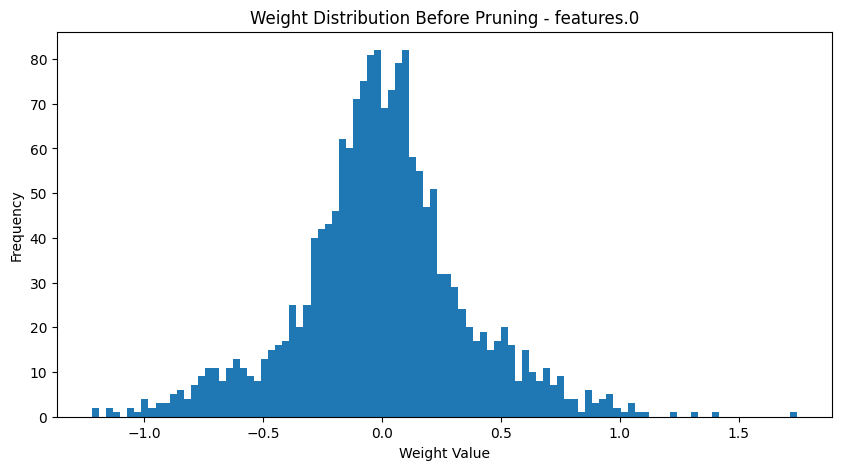

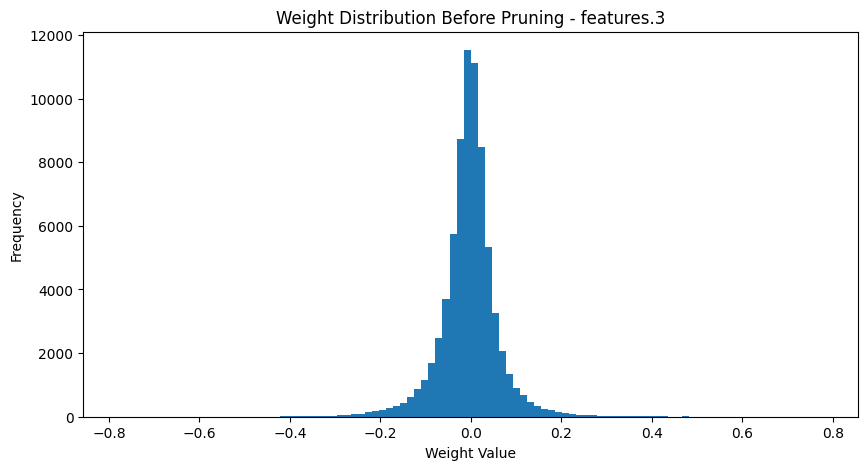

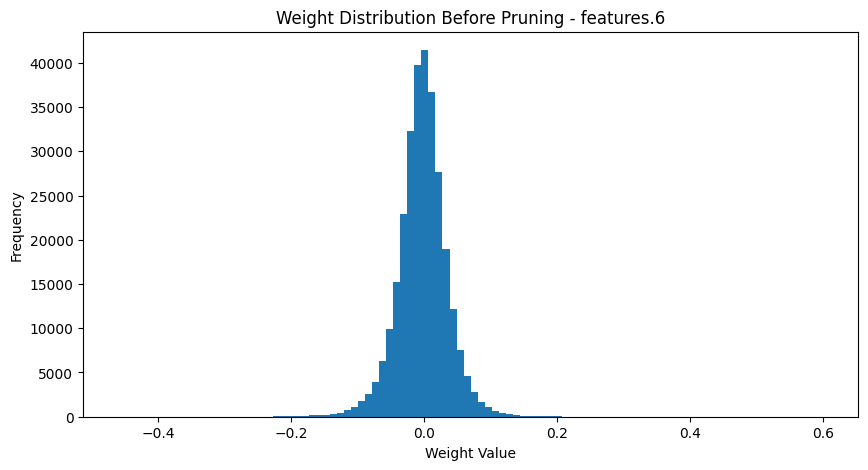

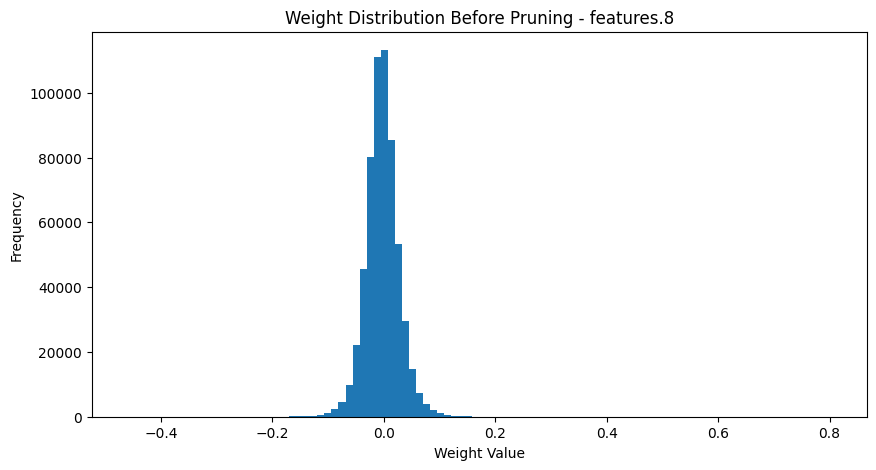

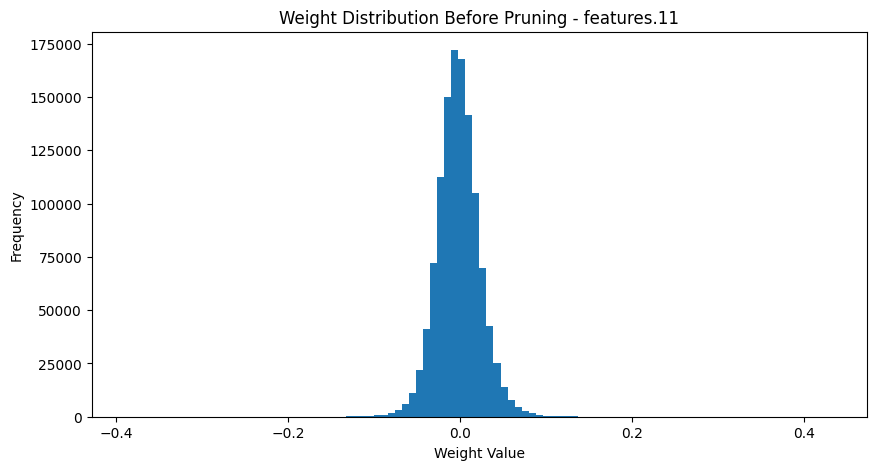

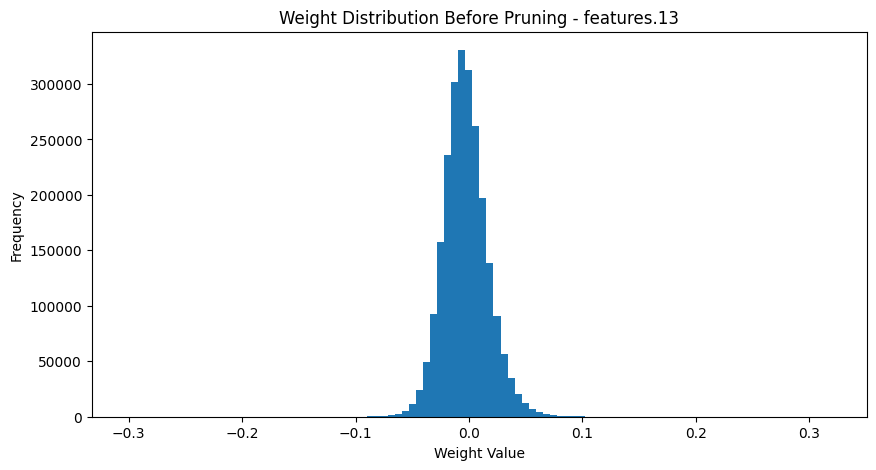

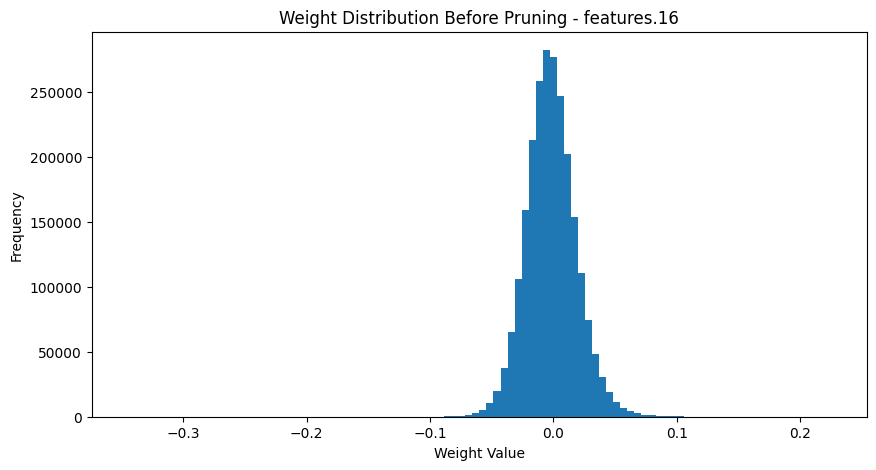

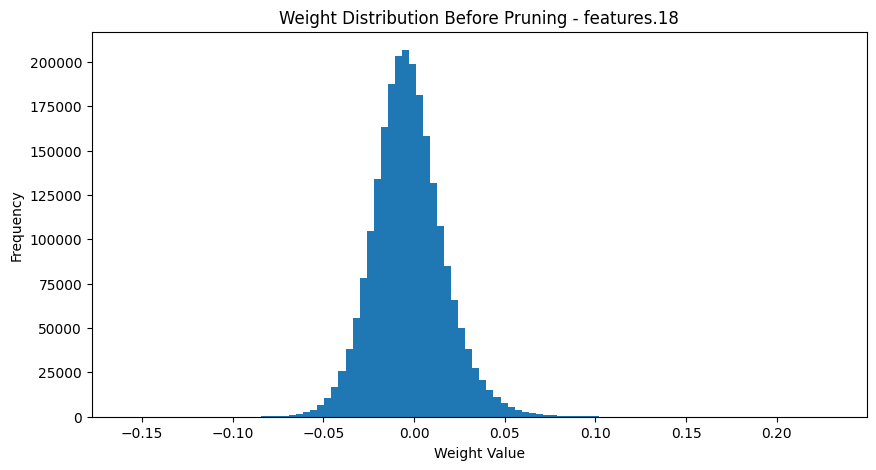

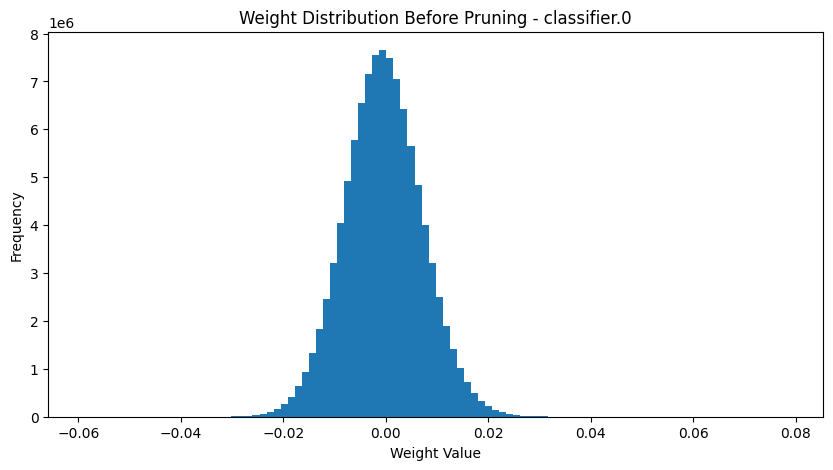

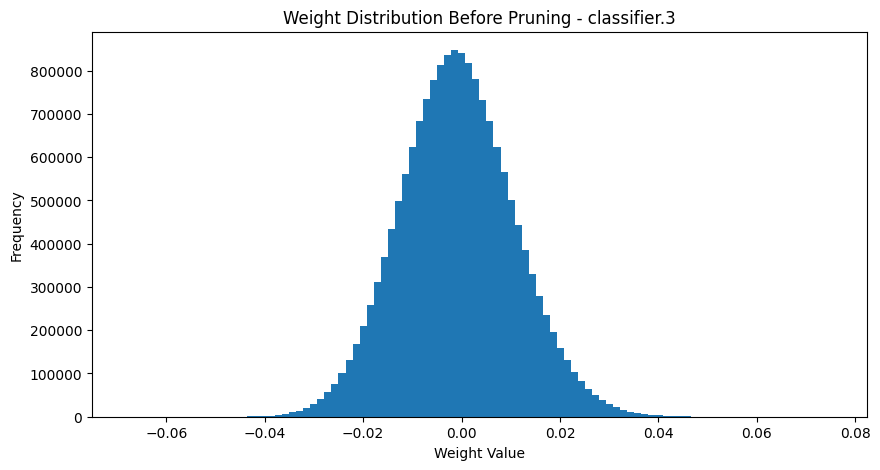

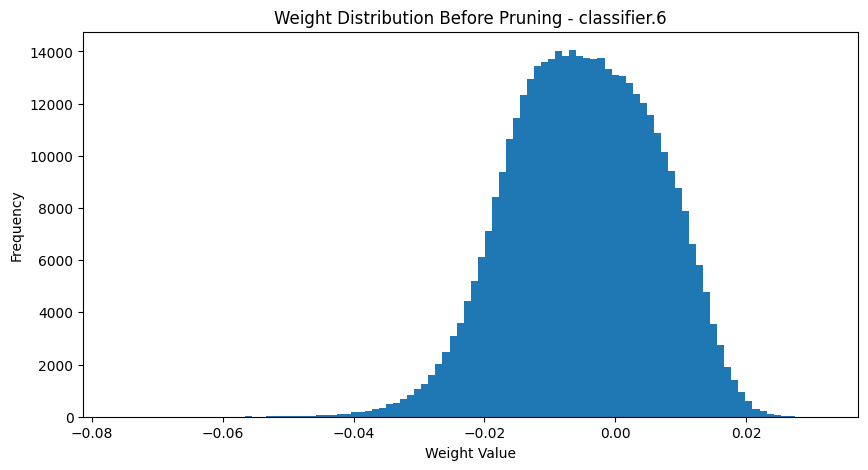

In [ ]:

weights_before = get_weights_per_layer(model)

for layer_name, weight_values in weights_before.items():
    plot_weight_distribution([weight_values], f'Weight Distribution Before Pruning - {layer_name}')


In [ ]:
def prune_model_unstructured_gpu(model, sparsity):
    device = next(model.parameters()).device

    all_weights = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            all_weights.append(module.weight.data.abs().view(-1))

    all_weights = torch.cat(all_weights).to(device)
    total_params = len(all_weights)
    print(f"Total parameters: {total_params}")
    k = max(1, int(total_params * sparsity))
    print("Number of parameters to prune (k):", k)

    # threshold, _ = torch.kthvalue(all_weights, k)
    threshold, _ = torch.topk(all_weights, k, largest=False, sorted=True)
    threshold = threshold[-1]
    print("Pruning threshold:", threshold)

    with torch.no_grad():
        for name, module in model.named_modules():
            if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
                weight_copy = module.weight.data.abs()
                mask = weight_copy.gt(threshold).float().to(device)
                module.weight.data.mul_(mask)

    zero_params = 0
    for module in model.modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            zero_params += (module.weight.data == 0).sum().item()

    actual_sparsity = zero_params / total_params
    print(f"Actual sparsity after pruning: {actual_sparsity:.4f}")


In [ ]:
prune_model_unstructured_gpu(model, sparsity=0.9)

Total parameters: 129164992
Number of parameters to prune (k): 116248492
Pruning threshold: tensor(0.0148, device='cuda:0')
Actual sparsity after pruning: 0.9000


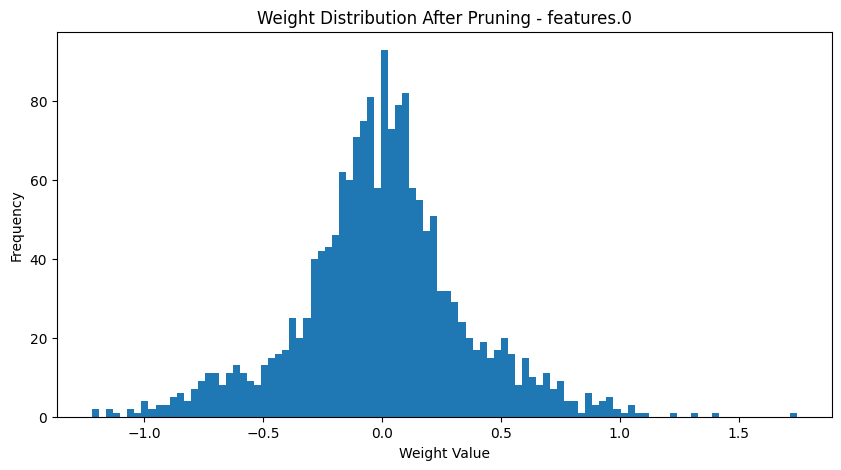

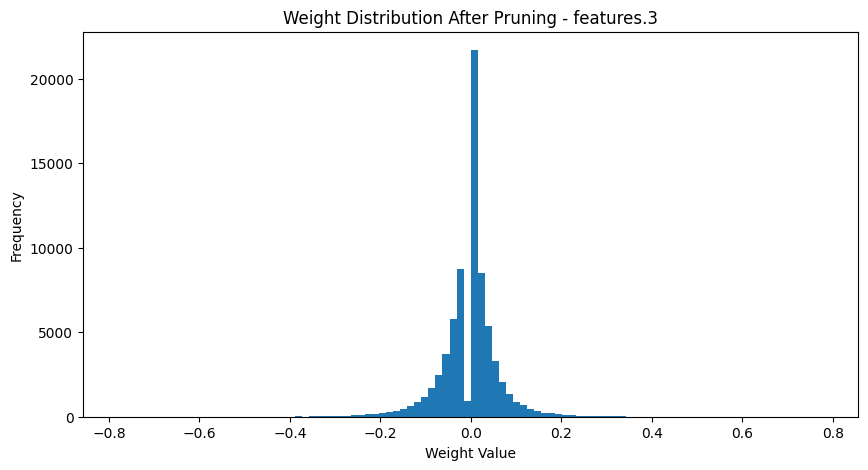

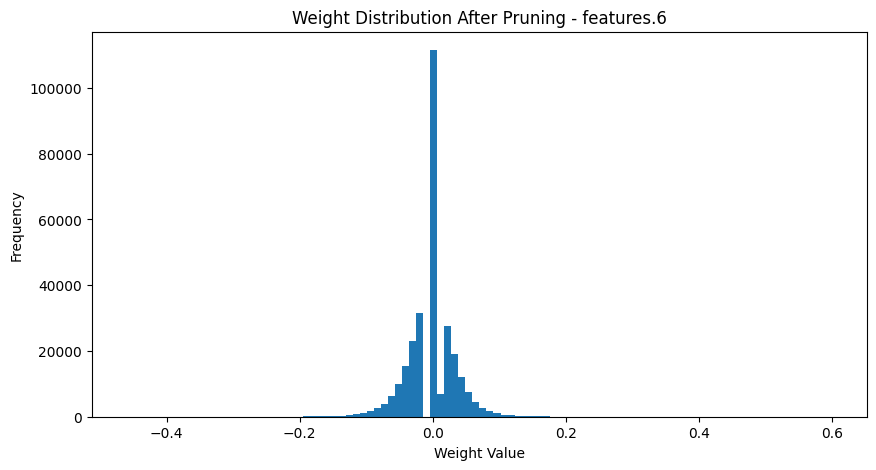

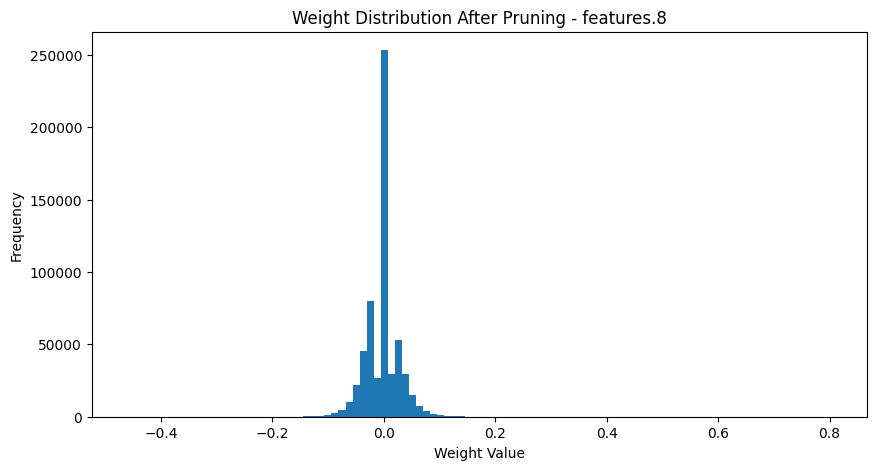

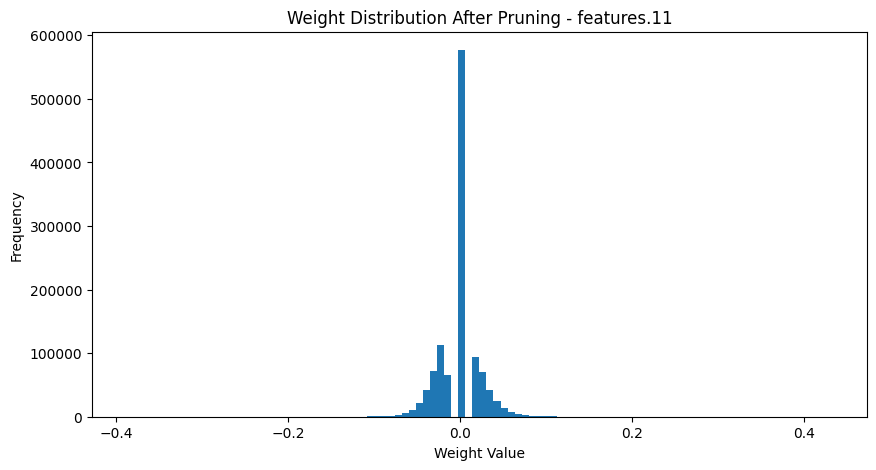

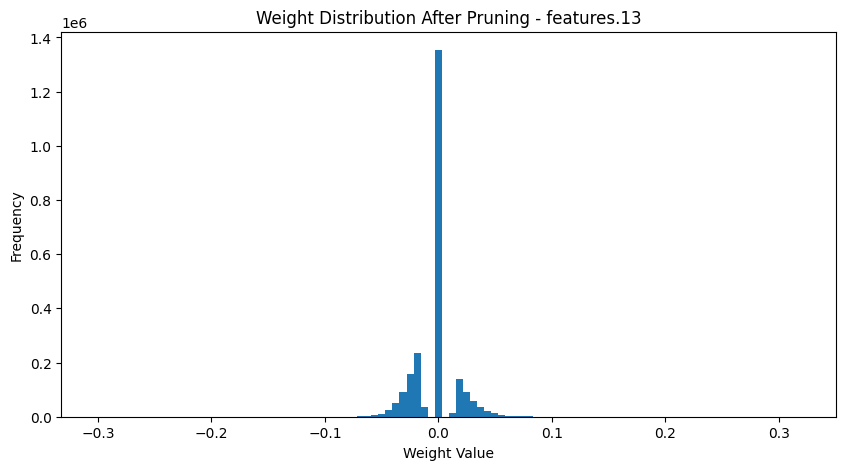

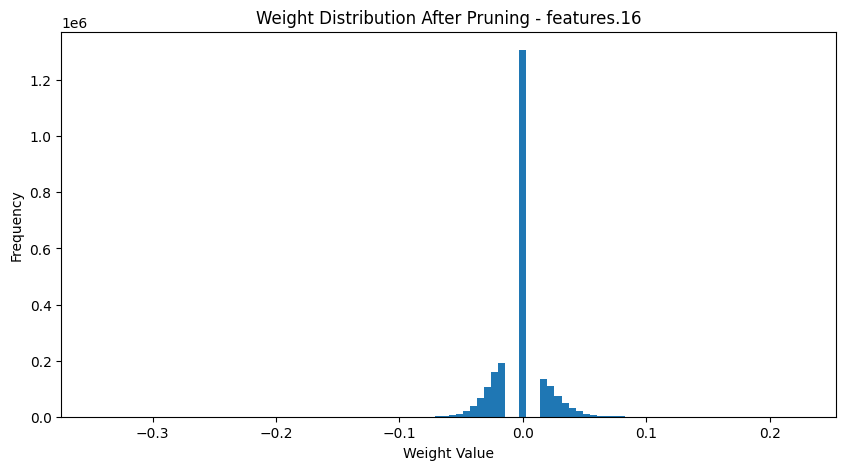

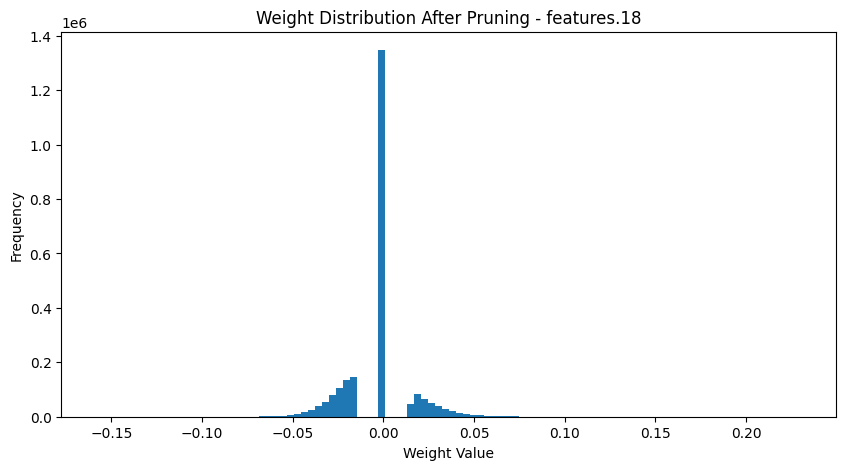

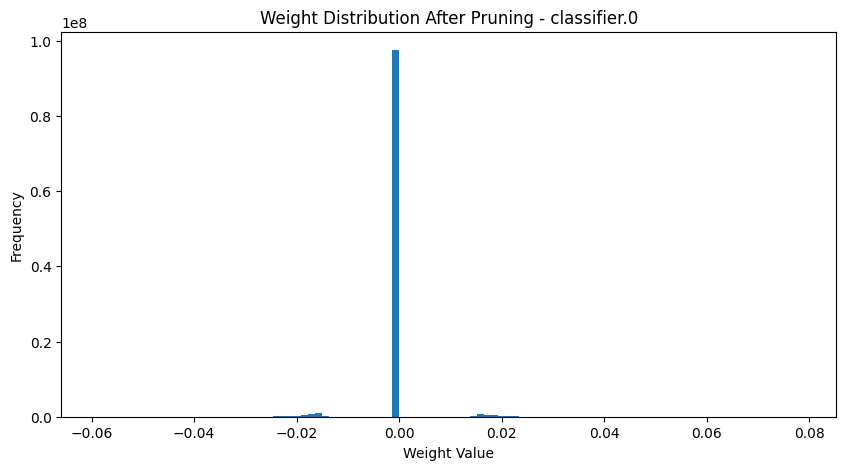

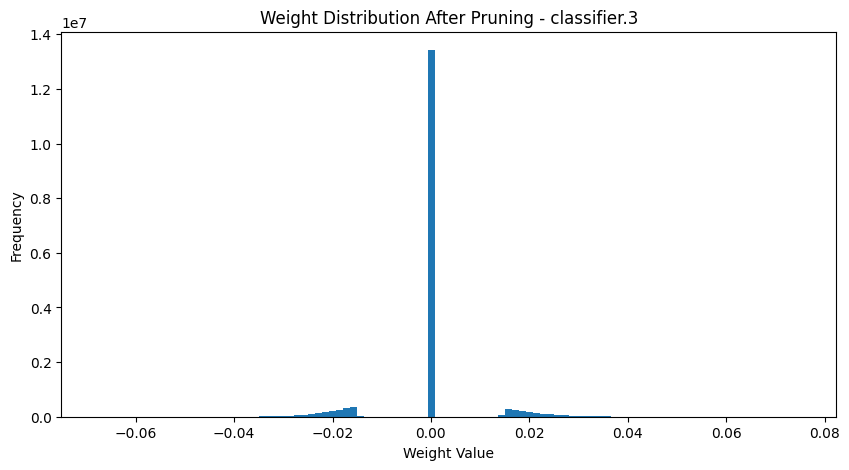

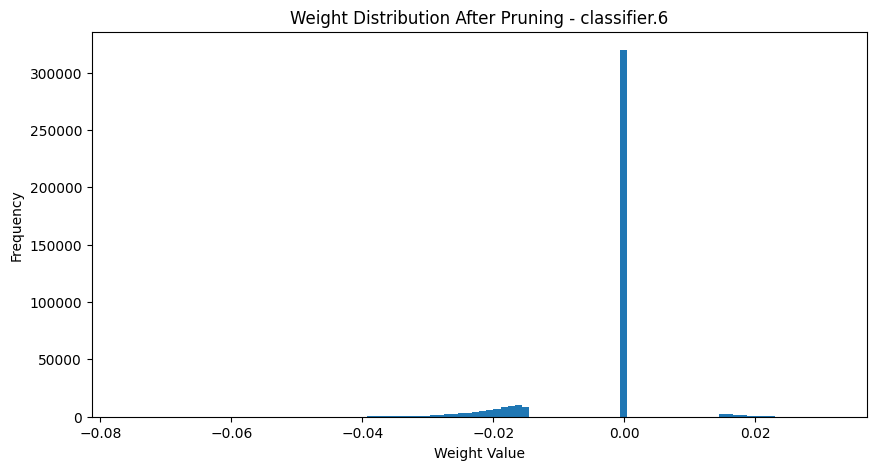

In [ ]:
weights_after = get_weights_per_layer(model)

for layer_name, weight_values in weights_after.items():
    plot_weight_distribution([weight_values], f'Weight Distribution After Pruning - {layer_name}')

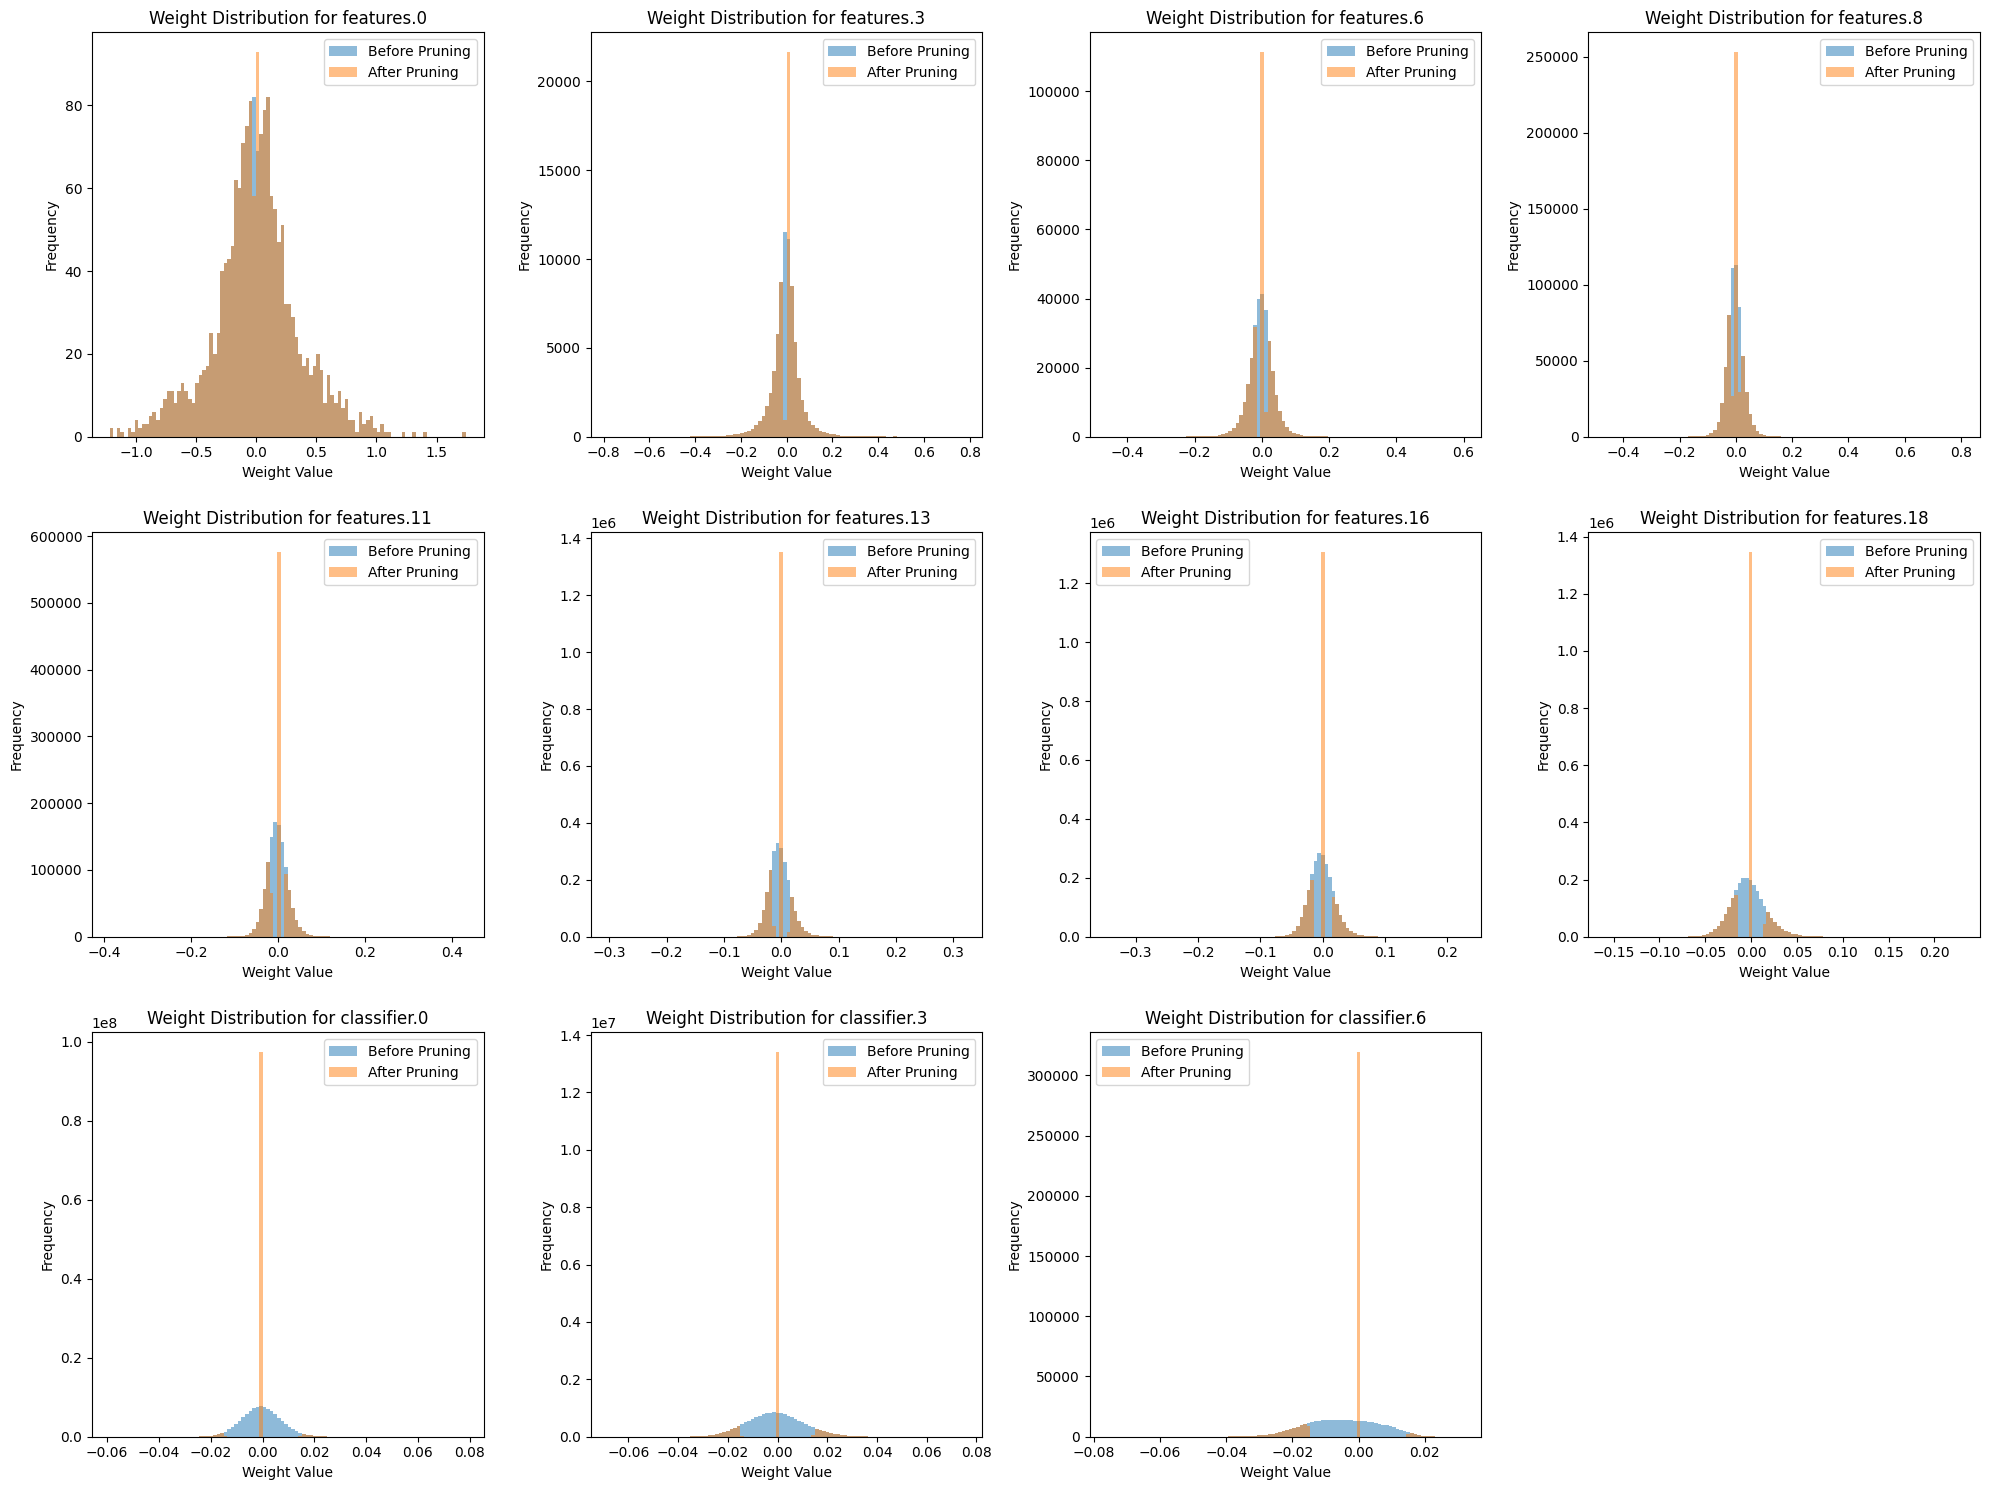

In [ ]:
import matplotlib.pyplot as plt

layer_names = list(weights_before.keys())
num_layers = len(layer_names)

# Determine the grid size
cols = 4
rows = (num_layers + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for idx, layer_name in enumerate(layer_names):
    ax = axes[idx]
    ax.hist(weights_before[layer_name], bins=100, alpha=0.5, label='Before Pruning')
    if layer_name in weights_after:
        ax.hist(weights_after[layer_name], bins=100, alpha=0.5, label='After Pruning')
    ax.set_title(f'Weight Distribution for {layer_name}')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Frequency')
    ax.legend()

# Remove unused subplots
for idx in range(len(layer_names), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('weight_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
accuracy_after = test(model, testloader)


100%|██████████| 157/157 [00:28<00:00,  5.41batch/s]

6391
10000
Accuracy on test set: 63.91%


In [ ]:
layer_names = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
        layer_names.append(name)
print("Layers to analyze:", layer_names)


Layers to analyze: ['features.0', 'features.3', 'features.6', 'features.8', 'features.11', 'features.13', 'features.16', 'features.18', 'classifier.0', 'classifier.3', 'classifier.6']


In [ ]:
sparsity_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]


In [ ]:
def prune_layer_unstructured(model, layer_name, sparsity):
    for name, module in model.named_modules():
        if name == layer_name:
            weight = module.weight.data.abs()
            flattened_weights = weight.flatten()
            total_weights = len(flattened_weights)
            k = int(total_weights * sparsity)
            if k == 0:
                print(f"No weights will be pruned in layer '{layer_name}' due to low sparsity.")
                break
            threshold, _ = torch.kthvalue(flattened_weights, k)
            print(f"Pruning layer '{layer_name}':")
            print(f"Total weights: {total_weights}, Weights to prune: {k}")
            print(f"Pruning threshold: {threshold.item()}")
            mask = weight.gt(threshold).float().to(module.weight.device)
            with torch.no_grad():
                module.weight.mul_(mask)
            zero_params = (module.weight.data == 0).sum().item()
            actual_sparsity = zero_params / total_weights
            print(f"Layer '{layer_name}' actual sparsity after pruning: {actual_sparsity:.4f}")
            break


In [ ]:
sensitivity_results_unstruc = {}

model.load_state_dict(torch.load('/content/drive/MyDrive/atml_pa3/vgg11_trained (1).pth'))

for layer_name in layer_names:
    print(f"==================layer name: {layer_name}============================")
    accuracies = []
    for sparsity in sparsity_ratios:
        print(f"==================sparisty level: {sparsity}============================")
        temp_model = copy.deepcopy(model)
        prune_layer_unstructured(temp_model, layer_name, sparsity)
        accuracy = test(temp_model, testloader)
        accuracies.append(accuracy)
    sensitivity_results_unstruc[layer_name] = accuracies


<ipython-input-37-5ddebdab448d>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/atml_pa3/vgg11_trained (1).pth'))


==================layer name: features.0============================
==================sparisty level: 0.1============================
Pruning layer 'features.0':
Total weights: 1728, Weights to prune: 172
Pruning threshold: 0.033940233290195465
Layer 'features.0' actual sparsity after pruning: 0.0995


100%|██████████| 157/157 [00:32<00:00,  4.80batch/s]


7204
10000
Accuracy on test set: 72.04%
==================sparisty level: 0.3============================
Pruning layer 'features.0':
Total weights: 1728, Weights to prune: 518
Pruning threshold: 0.09803318232297897
Layer 'features.0' actual sparsity after pruning: 0.2998


100%|██████████| 157/157 [00:32<00:00,  4.79batch/s]


...

7214
10000
Accuracy on test set: 72.14%
==================sparisty level: 0.7============================
Pruning layer 'classifier.6':
Total weights: 409600, Weights to prune: 286720
Pruning threshold: 0.012789475731551647
Layer 'classifier.6' actual sparsity after pruning: 0.7000


100%|██████████| 157/157 [00:30<00:00,  5.20batch/s]


7105
10000
Accuracy on test set: 71.05%
==================sparisty level: 0.9============================
Pruning layer 'classifier.6':
Total weights: 409600, Weights to prune: 368640
Pruning threshold: 0.01933443918824196
Layer 'classifier.6' actual sparsity after pruning: 0.9000


100%|██████████| 157/157 [00:30<00:00,  5.20batch/s]

6606
10000
Accuracy on test set: 66.06%


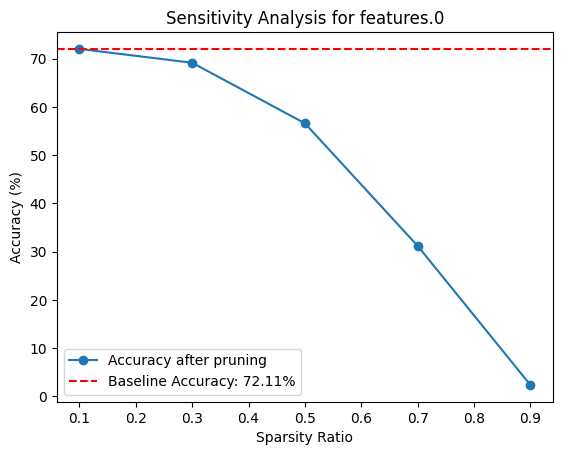

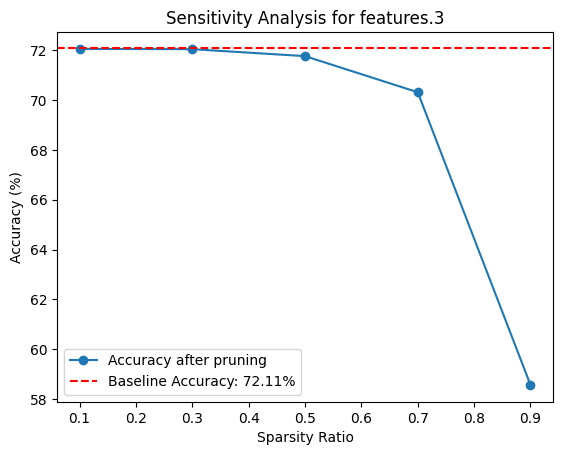

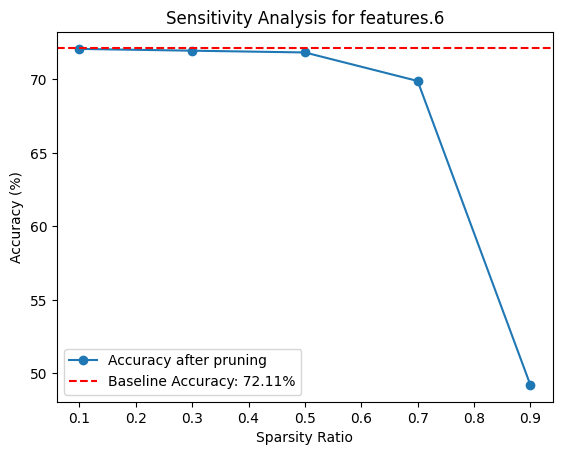

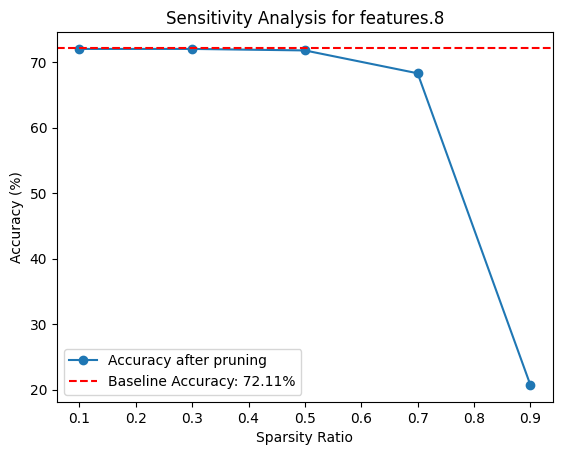

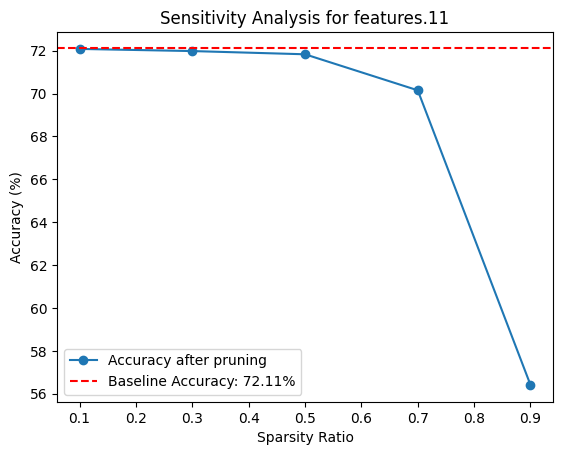

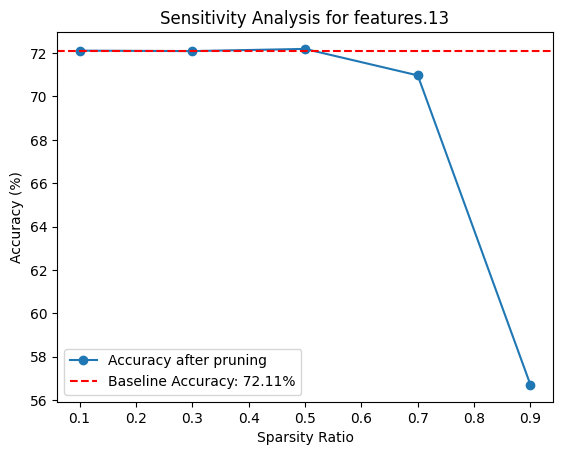

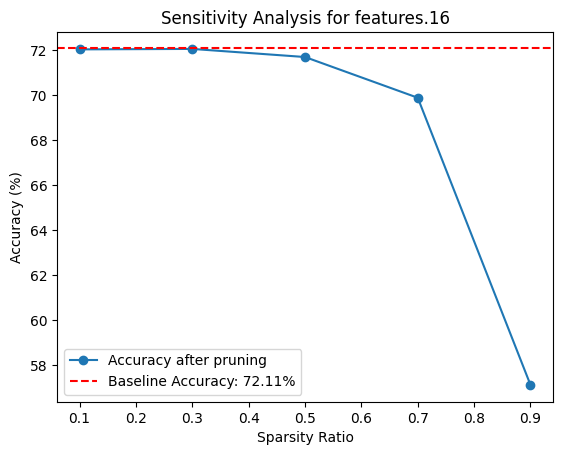

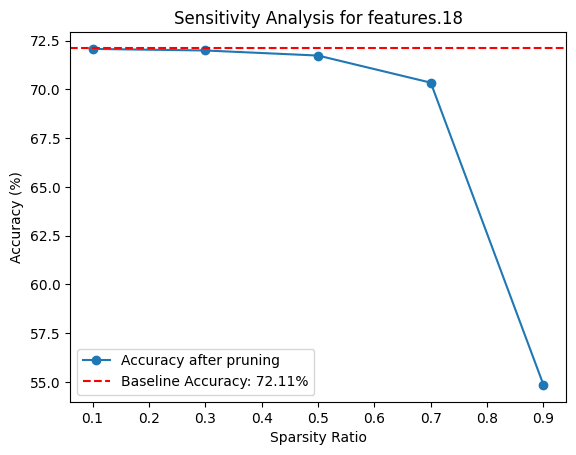

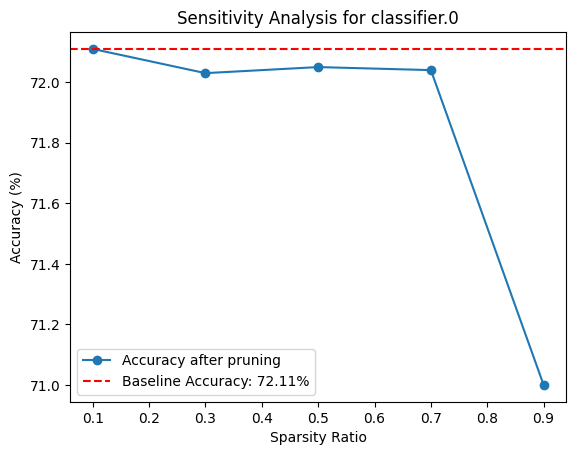

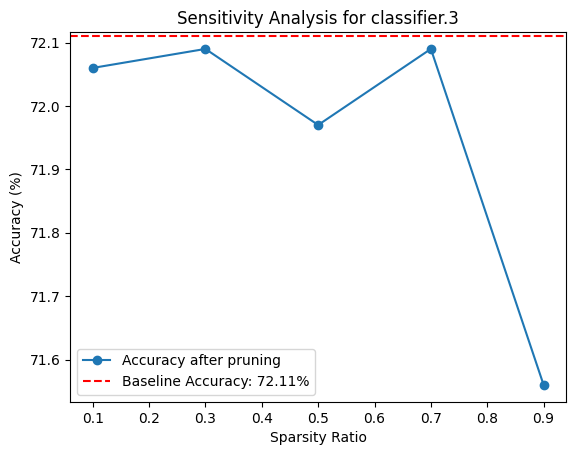

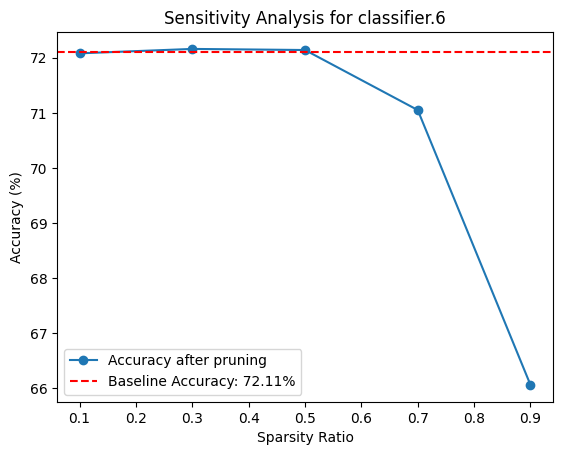

In [ ]:
for layer_name in sensitivity_results_unstruc:
    plt.figure()
    plt.plot(sparsity_ratios, sensitivity_results_unstruc[layer_name], marker='o', label="Accuracy after pruning")
    plt.axhline(y=72.11, color='r', linestyle='--', label=f"Baseline Accuracy: {72.11}%")
    plt.xlabel("Sparsity Ratio")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Sensitivity Analysis for {layer_name}")
    plt.legend()
    plt.show()

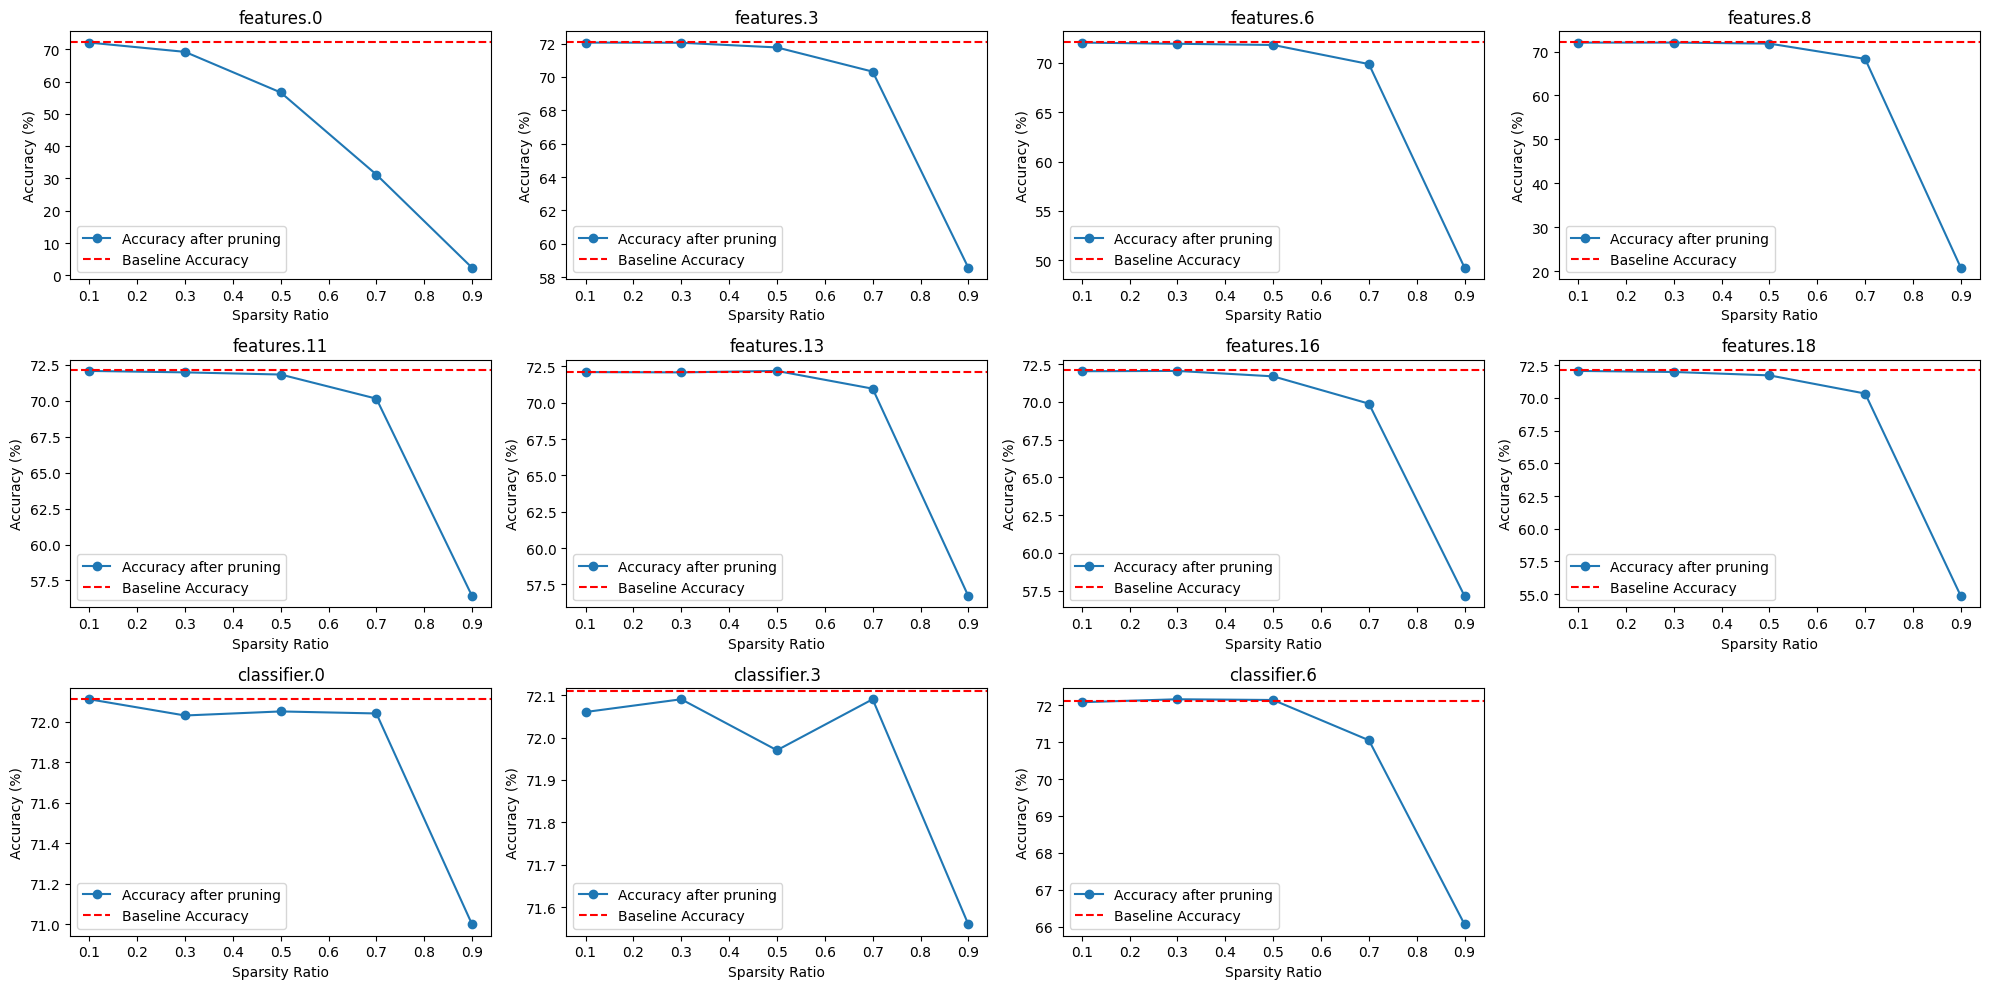

In [ ]:
import matplotlib.pyplot as plt
layer_names = list(sensitivity_results_unstruc.keys())
num_layers = len(layer_names)

# rows = 2
cols = 4
rows = (num_layers + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 10))
axes = axes.flatten()

for ax, (layer_name, accuracies) in zip(axes, sensitivity_results_unstruc.items()):
    ax.plot(
        sparsity_ratios,
        accuracies,
        marker='o',
        label="Accuracy after pruning"
    )
    ax.axhline(y=72.11, color='r', linestyle='--', label="Baseline Accuracy")
    ax.set_xlabel("Sparsity Ratio")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"{layer_name}")
    ax.legend()

for ax in axes[len(sensitivity_results_unstruc):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [ ]:
model = models.vgg11(weights=VGG11_Weights.DEFAULT)
model.classifier[6] = nn.Linear(4096, 100)
model = model.to(device)

In [ ]:
layer_sparsity = {}
for name in layer_names:
    if 'features.0' in name:
        layer_sparsity[name] = 0.0
    elif 'features' in name:
        layer_sparsity[name] = 0.45
    elif 'classifier.0' in name or 'classifier.3' in name:
        layer_sparsity[name] = 0.24
    elif 'classifier.6' in name:
        layer_sparsity[name] = 0.0


In [ ]:
total_weights = 0
total_weights_to_prune = 0

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
        num_weights = module.weight.data.numel()
        total_weights += num_weights
        sparsity = layer_sparsity.get(name, 0)
        weights_to_prune = int(num_weights * sparsity)
        total_weights_to_prune += weights_to_prune

overall_sparsity = total_weights_to_prune / total_weights
model_size_before = total_weights * 4 / (1024 ** 2)
print(f"Model size before pruning: {model_size_before:.2f} MB")
print(f'Calculated Overall Sparsity: {overall_sparsity * 100:.2f}%')


Model size before pruning: 492.73 MB
Calculated Overall Sparsity: 25.42%


In [ ]:
def prune_model_per_layer(model, layer_sparsity):
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            sparsity = layer_sparsity.get(name, 0)
            if sparsity > 0:
                # Get absolute values of the weights
                weight = module.weight.data.abs()
                flattened_weights = weight.view(-1)
                k = int(len(flattened_weights) * sparsity)
                if k == 0:
                    continue
                # Determine the threshold
                threshold, _ = torch.kthvalue(flattened_weights, k)
                # Create the mask
                mask = weight.ge(threshold).float()
                mask = mask.to(module.weight.device)
                with torch.no_grad():
                    # Apply the mask to the weights
                    module.weight.data.mul_(mask)
                # Store the mask as a buffer
                module.register_buffer('weight_mask', mask)
                # Remove previous hook if any
                if hasattr(module, 'weight_hook_handle'):
                    module.weight_hook_handle.remove()
                # Define a hook function without capturing the mask
                def backward_hook(grad, module=module):
                    return grad * module.weight_mask
                module.weight_hook_handle = module.weight.register_hook(backward_hook)
            else:
                # Remove existing hook and mask if any
                if hasattr(module, 'weight_hook_handle'):
                    module.weight_hook_handle.remove()
                    del module.weight_hook_handle
                if hasattr(module, 'weight_mask'):
                    del module.weight_mask






model.load_state_dict(torch.load('vgg11_trained.pth'))
prune_model_per_layer(model, layer_sparsity)


/tmp/ipykernel_30/1784068391.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vgg11_trained.pth'))


In [ ]:
def calculate_model_sparsity(model):
    total_params = 0
    zero_params = 0
    for module in model.modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            weight = module.weight.data.cpu().numpy()
            total_params += weight.size
            zero_params += np.sum(weight == 0)
    sparsity = zero_params / total_params
    print(f'Total parameters: {total_params}')
    print(f'Zero parameters: {zero_params}')
    print(f'Overall sparsity: {sparsity * 100:.2f}%')
    return sparsity

calculate_model_sparsity(model)


Total parameters: 129164992
Zero parameters: 32836223
Overall sparsity: 25.42%


0.25421921599313846

In [ ]:
accuracy_before_finetune = test(model, testloader)

100%|██████████| 157/157 [00:26<00:00,  5.82batch/s]

7064
10000
Accuracy on test set: 70.64%


In [ ]:
torch.save(model.state_dict(), 'vgg11_trained_pruned_unstructured_BF_updated_twice.pth')

In [ ]:
import gc

# Before starting training
gc.collect()
torch.cuda.empty_cache()


In [ ]:
optimizer_ft = optim.AdamW(model.parameters(), lr=1e-4)
train(model, trainloader, criterion, optimizer_ft, num_epochs=3)

Epoch 3: 100%|██████████| 782/782 [09:04<00:00,  1.44batch/s, accuracy=97.6, loss=0.088] 

Finished Training


In [ ]:
accuracy_final = test(model, testloader)


100%|██████████| 157/157 [00:26<00:00,  5.94batch/s]

7169
10000
Accuracy on test set: 71.69%


In [ ]:
torch.save(model.state_dict(), 'vgg11_trained_pruned_unstructured_AF.pth')

In [ ]:
def verify_pruned_weights(model):
    for name, module in model.named_modules():
        if hasattr(module, 'weight_mask'):
            pruned_weights = module.weight.data[module.weight_mask == 0]
            if pruned_weights.abs().sum().item() != 0:
                print(f"Pruned weights updated in layer {name}")
            else:
                print(f"Pruned weights remain zero in layer {name}")

verify_pruned_weights(model)


Pruned weights remain zero in layer features.3
Pruned weights remain zero in layer features.6
Pruned weights remain zero in layer features.8
Pruned weights remain zero in layer features.11
Pruned weights remain zero in layer features.13
Pruned weights remain zero in layer features.16
Pruned weights remain zero in layer features.18
Pruned weights remain zero in layer classifier.0
Pruned weights remain zero in layer classifier.3


In [ ]:
model = models.vgg11(weights=VGG11_Weights.DEFAULT)
model.classifier[6] = nn.Linear(4096, 100)
model = model.to(device)

In [ ]:
import time

def measure_inference_time(model, device, input_size=(1, 3, 224, 224), runs=100):
    model.eval()
    input_data = torch.randn(input_size).to(device)
    for _ in range(10):
        _ = model(input_data)

    # Measure inference time
    start_time = time.time()
    for _ in range(runs):
        _ = model(input_data)
    end_time = time.time()

    avg_inference_time = (end_time - start_time) / runs
    print(f"Average inference time over {runs} runs: {avg_inference_time * 1000:.2f} ms")
    return avg_inference_time

model.load_state_dict(torch.load('vgg11_trained.pth'))
inference_time_before = measure_inference_time(model, device)

model = models.vgg11(weights=VGG11_Weights.DEFAULT)
model.classifier[6] = nn.Linear(4096, 100)
model = model.to(device)



/tmp/ipykernel_30/1258152645.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vgg11_trained.pth'))


Average inference time over 100 runs: 5.39 ms


In [ ]:
# Define your layer_sparsity dictionary
layer_sparsity = {
    'features.0': 0.0,
    'features.3': 0.15,
    'features.6': 0.15,
    'features.8': 0.15,
    'features.11': 0.15,
    'features.13': 0.15,
    'features.16': 0.15,
    'features.18': 0.15,
    'classifier.0': 0.26,
    'classifier.3': 0.26,
    'classifier.6': 0.0
}

# Apply pruning to the model
prune_model_per_layer(model, layer_sparsity)


In [ ]:
model.load_state_dict(torch.load('vgg11_trained_pruned_unstructured_AF.pth'))
inference_time_after = measure_inference_time(model, device)

/tmp/ipykernel_30/3921602233.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vgg11_trained_pruned_unstructured_AF.pth'))


Average inference time over 100 runs: 5.31 ms


In [ ]:

speedup = inference_time_before / inference_time_after
print(f"Inference time before pruning: {inference_time_before * 1000:.2f} ms")
print(f"Inference time after pruning: {inference_time_after * 1000:.2f} ms")
print(f"Speedup factor: {speedup:.2f}x")


Inference time before pruning: 5.39 ms
Inference time after pruning: 5.31 ms
Speedup factor: 1.02x


# task 1.2

In [ ]:
model = models.vgg11(weights=VGG11_Weights.DEFAULT)
model.classifier[6] = nn.Linear(4096, 100)
model = model.to(device)

In [ ]:
model.load_state_dict(torch.load('/content/drive/MyDrive/atml_pa3/vgg11_trained (1).pth'))

<ipython-input-41-1e7c01474c28>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/atml_pa3/vgg11_trained (1).pth'))


<All keys matched successfully>

In [ ]:
def compute_channel_importance(module):
    if isinstance(module, nn.Conv2d):
        weight = module.weight.data.cpu().numpy()
        num_filters = weight.shape[0]
        print("num filter is: ", num_filters)
        importance = np.zeros(num_filters)
        for i in range(num_filters):
            filter_weights = weight[i, :, :, :]
            importance[i] = np.linalg.norm(filter_weights)
        return importance
    else:
        return None


In [ ]:
def plot_channel_importance(importance, title):
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(importance)), importance)
    plt.title(title)
    plt.xlabel('Channel Index')
    plt.ylabel('L2 Norm')
    plt.show()


In [ ]:
def get_weights_per_layer(model):
    weights = {}
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight.data.cpu().numpy()
            weights[name] = weight.flatten()
    return weights

def plot_weight_distribution(weights_dict, title):
    all_weights = np.concatenate(list(weights_dict.values()))
    plt.figure(figsize=(10, 5))
    plt.hist(all_weights, bins=100)
    plt.title(title)
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
def prune_conv_layer_classifier_fix(model, layer_name, num_channels_to_prune):

    module_list = dict(model.named_modules())
    conv = module_list[layer_name]
    next_name = None


    layer_found = False
    for name, module in model.named_modules():
        if layer_found and isinstance(module, nn.Conv2d):
            next_name = name
            break
        if name == layer_name:
            layer_found = True

    importance = compute_channel_importance(conv)
    prune_indices = np.argsort(importance)[:num_channels_to_prune]
    keep_indices = np.argsort(importance)[num_channels_to_prune:]
    new_out_channels = conv.out_channels - num_channels_to_prune
    new_conv = nn.Conv2d(
        in_channels=conv.in_channels,
        out_channels=new_out_channels,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        dilation=conv.dilation,
        groups=conv.groups,
        bias=(conv.bias is not None)
    ).to(conv.weight.device)

    new_conv.weight.data = conv.weight.data[keep_indices, :, :, :].clone()
    if conv.bias is not None:
        new_conv.bias.data = conv.bias.data[keep_indices].clone()

    parent_module = model
    hierarchy = layer_name.split('.')
    for h in hierarchy[:-1]:
        parent_module = getattr(parent_module, h)
    setattr(parent_module, hierarchy[-1], new_conv)

    if next_name:
        next_conv = module_list[next_name]
        new_in_channels = next_conv.in_channels - num_channels_to_prune
        new_next_conv = nn.Conv2d(
            in_channels=new_in_channels,
            out_channels=next_conv.out_channels,
            kernel_size=next_conv.kernel_size,
            stride=next_conv.stride,
            padding=next_conv.padding,
            dilation=next_conv.dilation,
            groups=next_conv.groups,
            bias=(next_conv.bias is not None)
        ).to(next_conv.weight.device)


        new_next_conv.weight.data = next_conv.weight.data[:, keep_indices, :, :].clone()
        if next_conv.bias is not None:
            new_next_conv.bias.data = next_conv.bias.data.clone()

        parent_module = model
        hierarchy = next_name.split('.')
        for h in hierarchy[:-1]:
            parent_module = getattr(parent_module, h)
        setattr(parent_module, hierarchy[-1], new_next_conv)
    else:
        input_height, input_width = 224, 224
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, input_height, input_width).to(conv.weight.device)
            output = model.features(dummy_input)
            print(f"Output shape before flattening: {output.shape}")
            channels = output.size(1)
            H = output.size(2)
            W = output.size(3)
            HW = H * W
            output = output.view(output.size(0), -1)
            new_in_features = output.size(1)

        classifier = model.classifier
        fc = classifier[0]
        new_fc = nn.Linear(
            in_features=new_in_features,
            out_features=fc.out_features,
            bias=(fc.bias is not None)
        ).to(fc.weight.device)

        old_in_features = fc.in_features
        old_channels = conv.out_channels
        old_HW = H * W
        assert old_in_features == old_channels * old_HW, "Mismatch in old in_features calculation"
        new_fc.weight.data.zero_()

        for new_idx, old_channel_idx in enumerate(keep_indices):
            old_start_idx = old_channel_idx * HW
            old_end_idx = (old_channel_idx + 1) * HW

            new_start_idx = new_idx * HW
            new_end_idx = (new_idx + 1) * HW

            new_fc.weight.data[:, new_start_idx:new_end_idx] = fc.weight.data[:, old_start_idx:old_end_idx].clone()

        if fc.bias is not None:
            new_fc.bias.data = fc.bias.data.clone()

        classifier[0] = new_fc


In [ ]:
layer_names = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        layer_names.append(name)
print("Convolutional layers to analyze:", layer_names)


Convolutional layers to analyze: ['features.0', 'features.3', 'features.6', 'features.8', 'features.11', 'features.13', 'features.16', 'features.18']


In [ ]:
weights_before = get_weights_per_layer(model)


Processing layer: features.0
num filter is:  64
Channel importance before pruning for features.0:


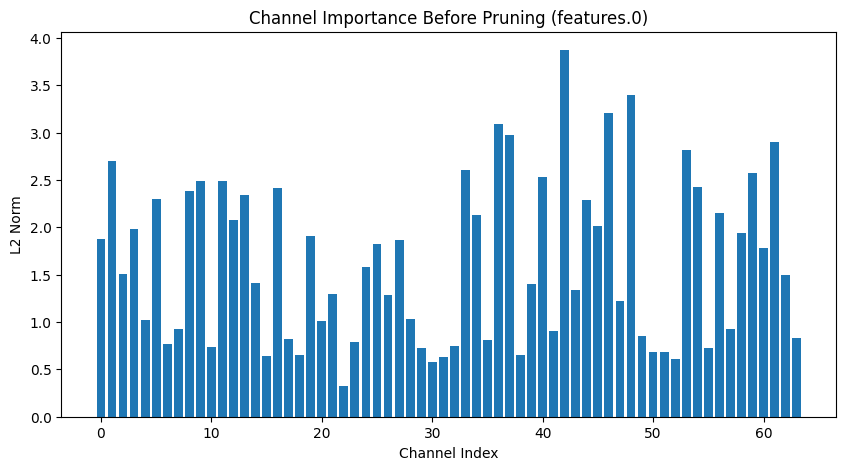


Processing layer: features.3
num filter is:  128
Channel importance before pruning for features.3:


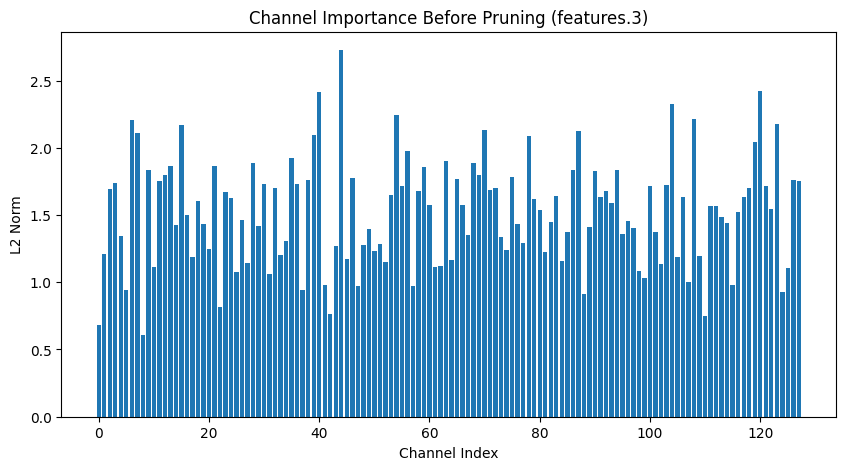


Processing layer: features.6
num filter is:  256
Channel importance before pruning for features.6:


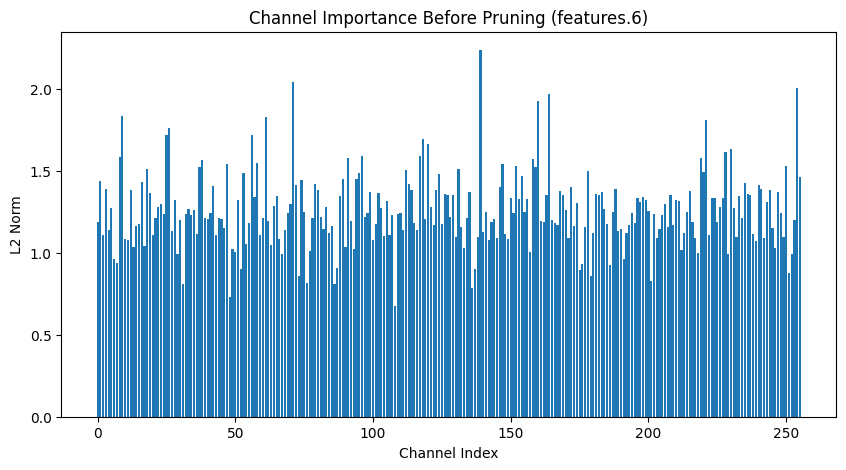


Processing layer: features.8
num filter is:  256
Channel importance before pruning for features.8:


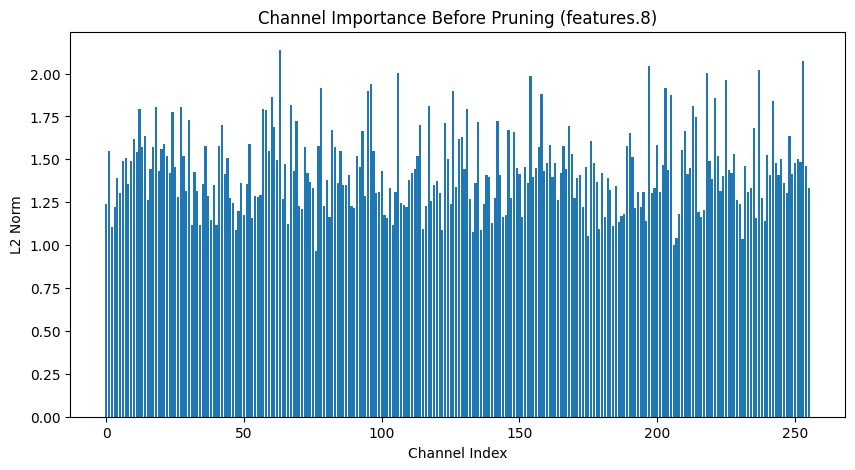


Processing layer: features.11
num filter is:  512
Channel importance before pruning for features.11:


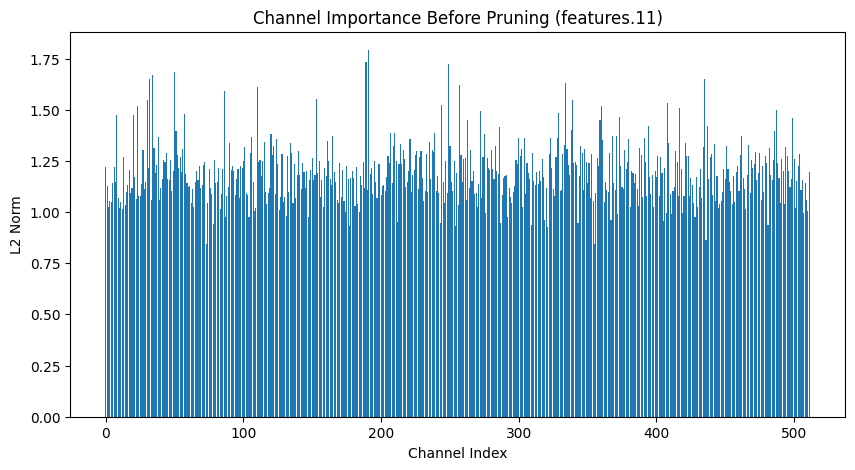


Processing layer: features.13
num filter is:  512
Channel importance before pruning for features.13:


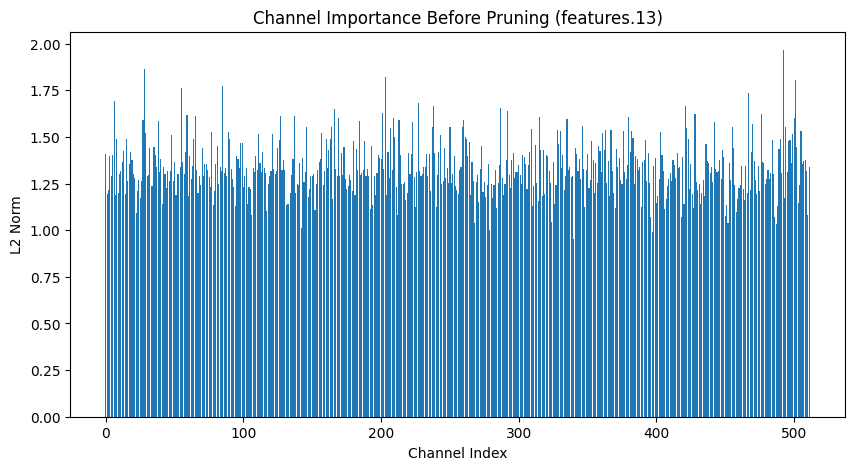


Processing layer: features.16
num filter is:  512
Channel importance before pruning for features.16:


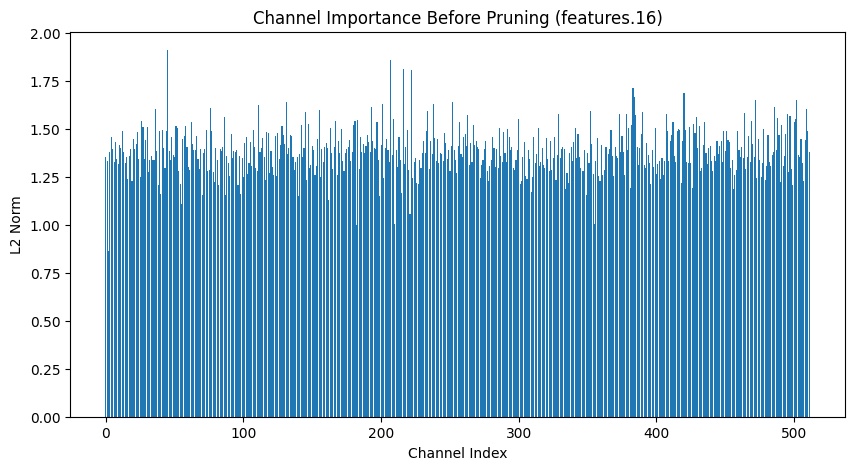


Processing layer: features.18
num filter is:  512
Channel importance before pruning for features.18:


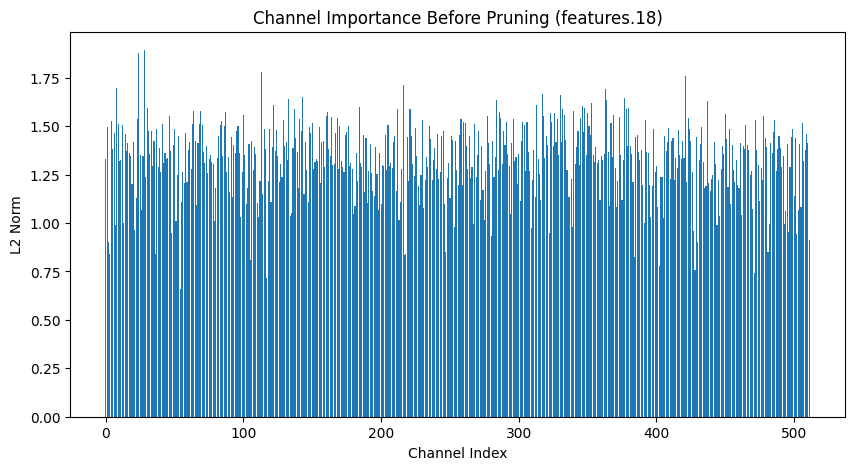

In [ ]:

for layer_name in layer_names:
    print(f"\nProcessing layer: {layer_name}")

    # Get the module
    module = dict(model.named_modules())[layer_name]

    # Compute and plot channel importance before pruning
    importance_before = compute_channel_importance(module)
    print(f"Channel importance before pruning for {layer_name}:")
    plot_channel_importance(importance_before, f'Channel Importance Before Pruning ({layer_name})')




Number of channels to prune in features.0: 16 out of 64
num filter is:  64
num filter is:  48
Channel importance after pruning for features.0:


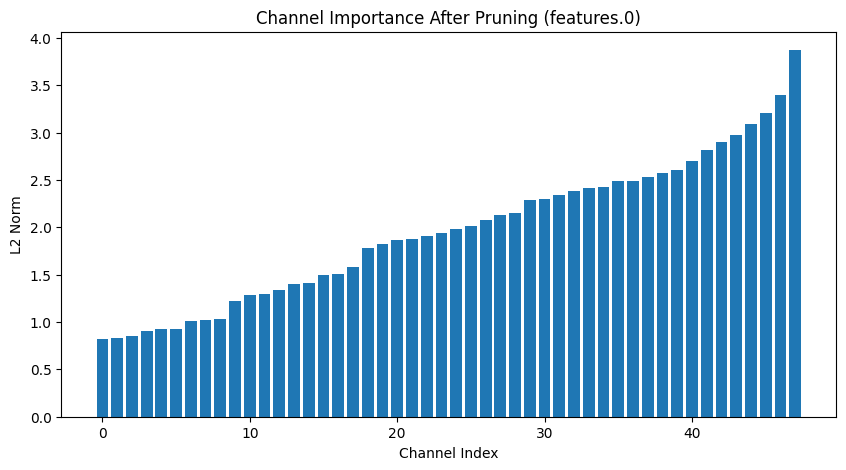

Number of channels to prune in features.3: 32 out of 128
num filter is:  128
num filter is:  96
Channel importance after pruning for features.3:


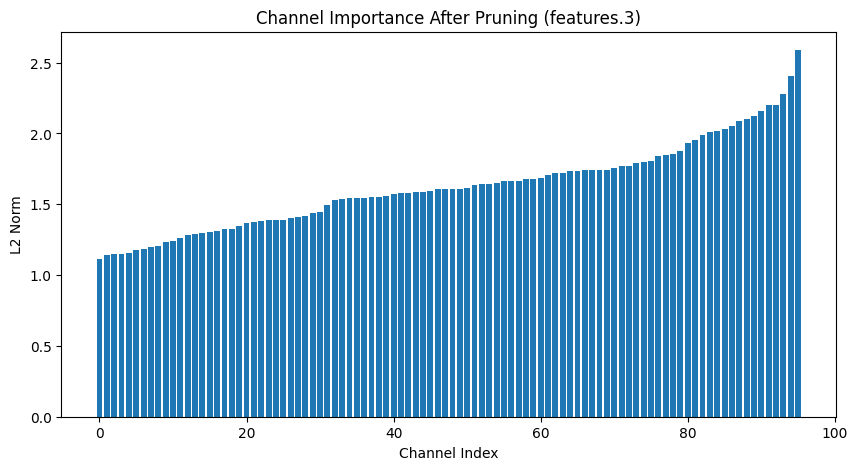

Number of channels to prune in features.6: 64 out of 256
num filter is:  256
num filter is:  192
Channel importance after pruning for features.6:


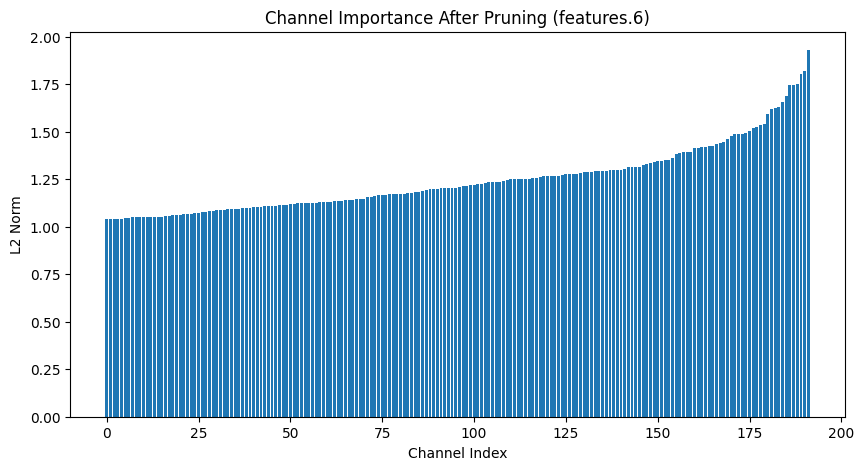

Number of channels to prune in features.8: 64 out of 256
num filter is:  256
num filter is:  192
Channel importance after pruning for features.8:


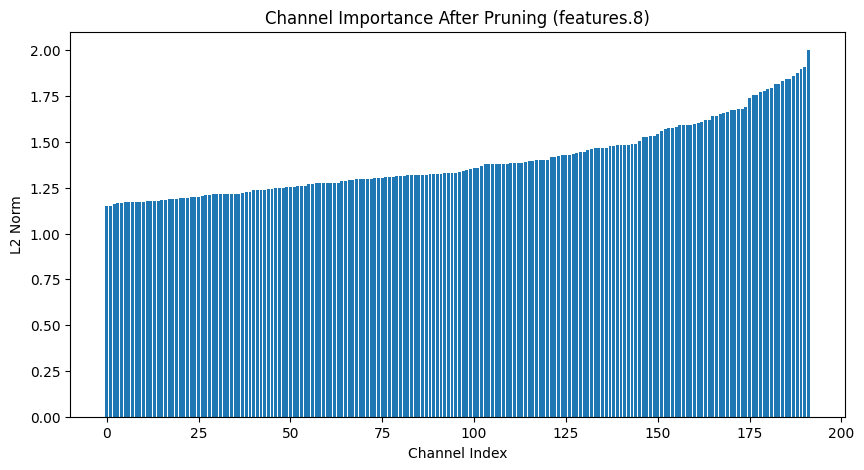

Number of channels to prune in features.11: 128 out of 512
num filter is:  512
num filter is:  384
Channel importance after pruning for features.11:


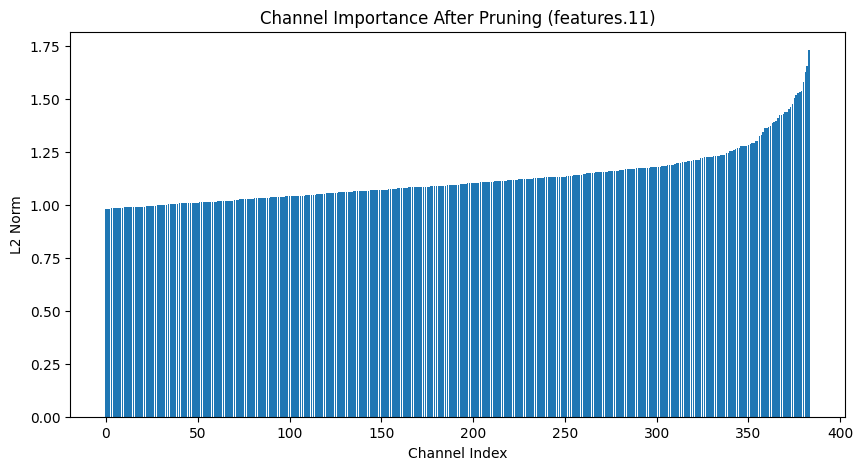

Number of channels to prune in features.13: 128 out of 512
num filter is:  512
num filter is:  384
Channel importance after pruning for features.13:


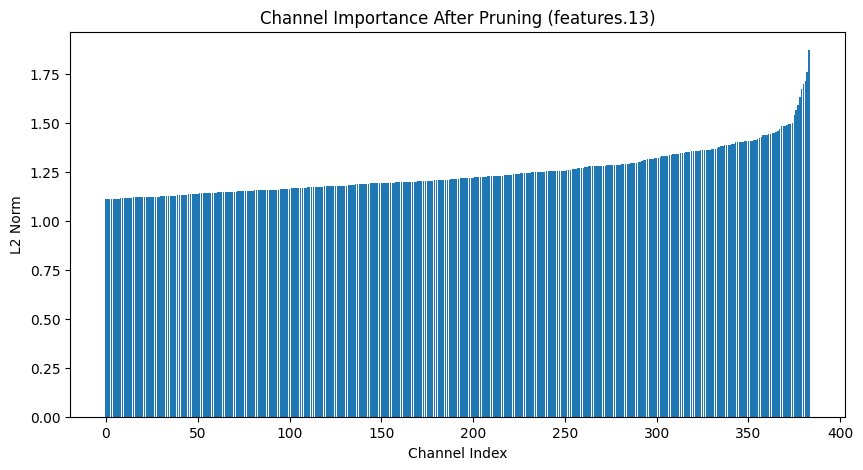

Number of channels to prune in features.16: 128 out of 512
num filter is:  512
num filter is:  384
Channel importance after pruning for features.16:


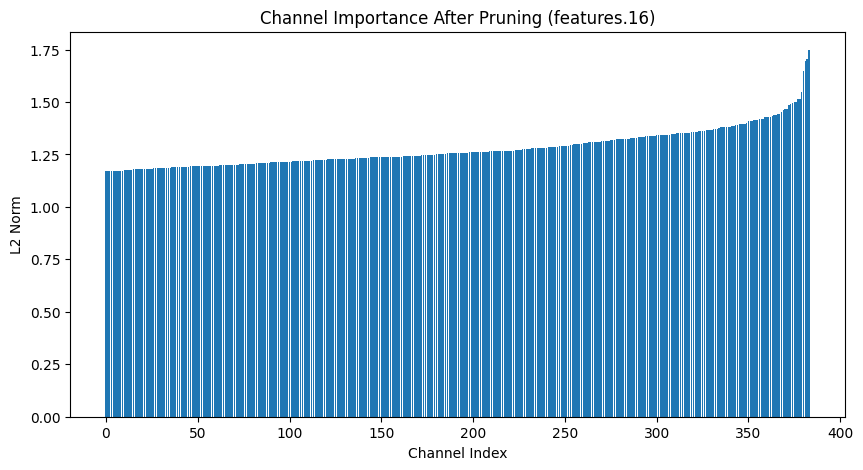

Number of channels to prune in features.18: 128 out of 512
num filter is:  512
Output shape before flattening: torch.Size([1, 384, 7, 7])
num filter is:  384
Channel importance after pruning for features.18:


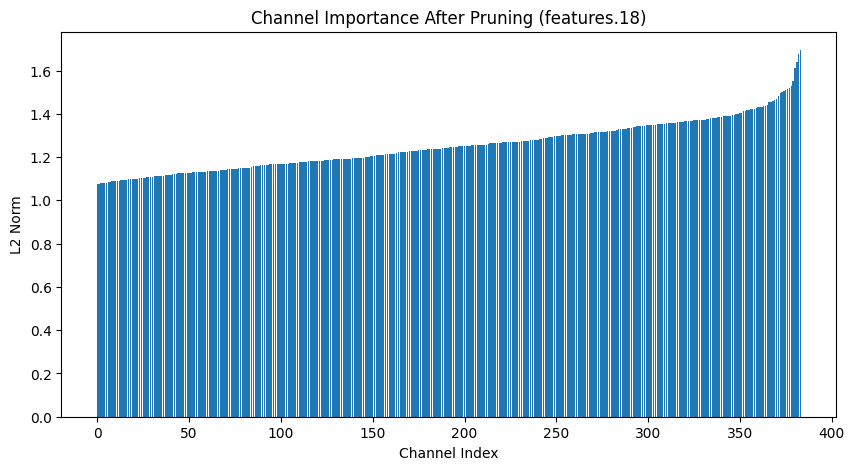

In [ ]:
for layer_name in layer_names:
    module = dict(model.named_modules())[layer_name]
    num_channels = module.out_channels
    num_channels_to_prune = int(num_channels * 0.25)
    print(f"Number of channels to prune in {layer_name}: {num_channels_to_prune} out of {num_channels}")
    prune_conv_layer_classifier_fix(model, layer_name, num_channels_to_prune)
    module = dict(model.named_modules())[layer_name]
    importance_after = compute_channel_importance(module)
    print(f"Channel importance after pruning for {layer_name}:")
    plot_channel_importance(importance_after, f'Channel Importance After Pruning ({layer_name})')

In [ ]:
# Collect weights after pruning
weights_after = get_weights_per_layer(model)

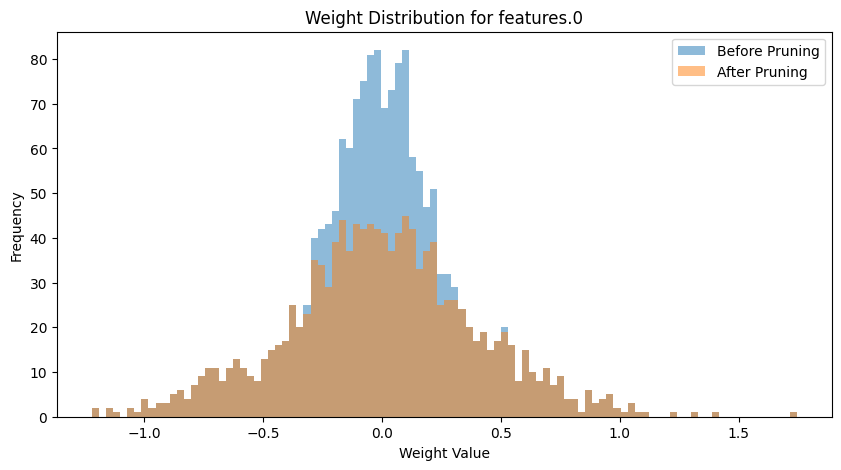

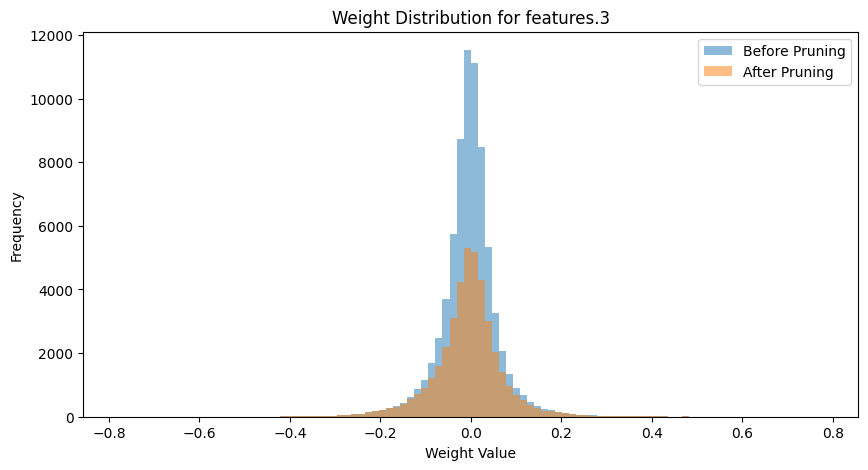

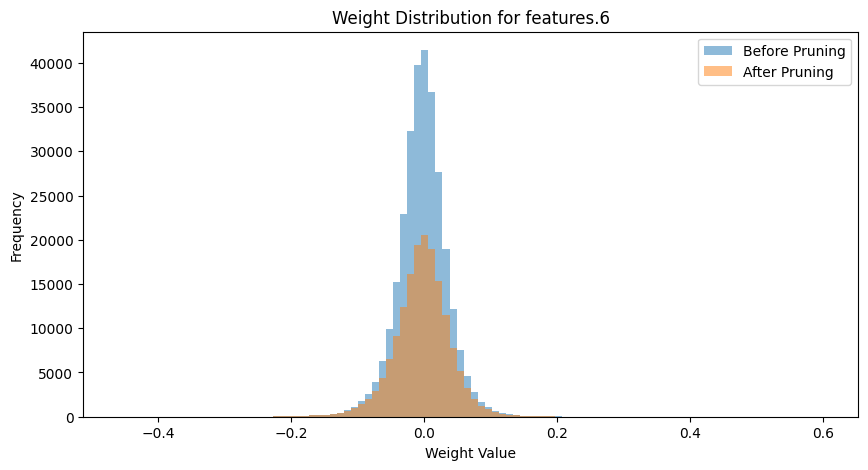

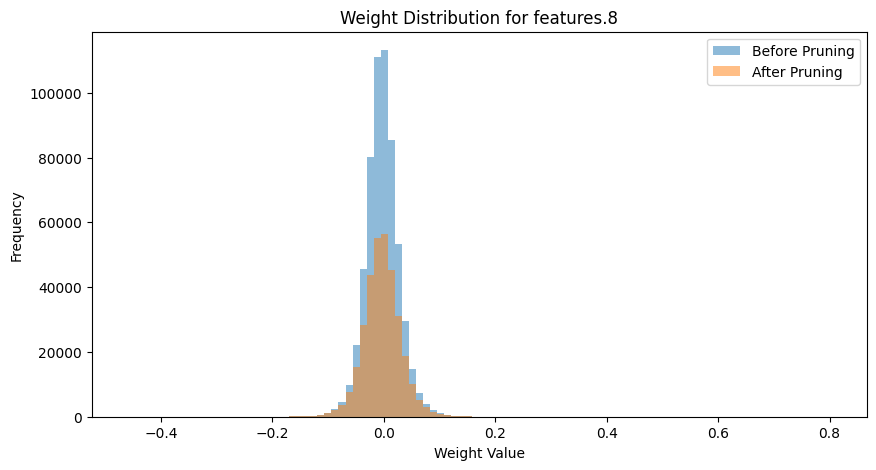

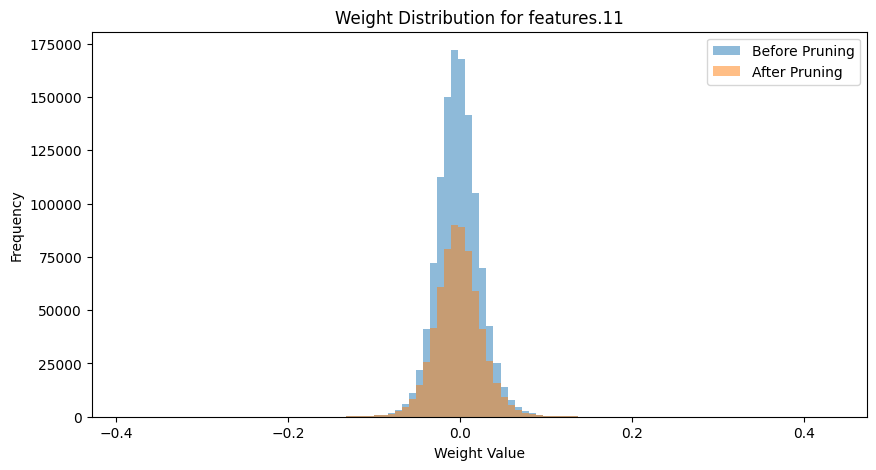

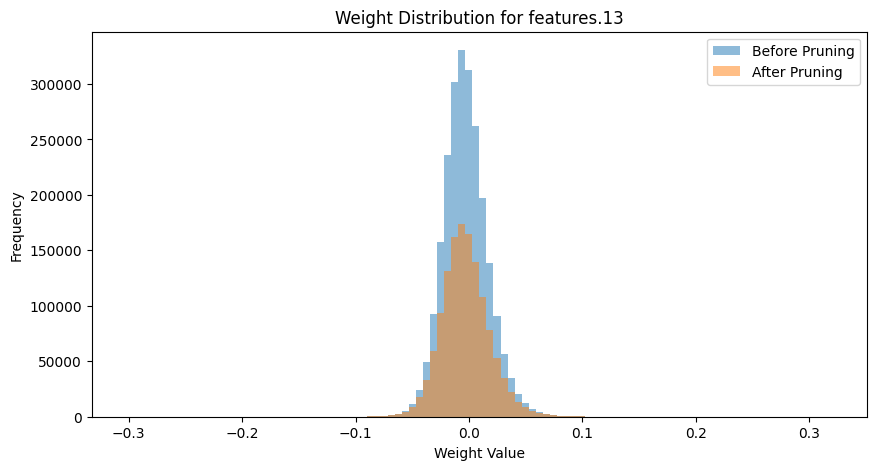

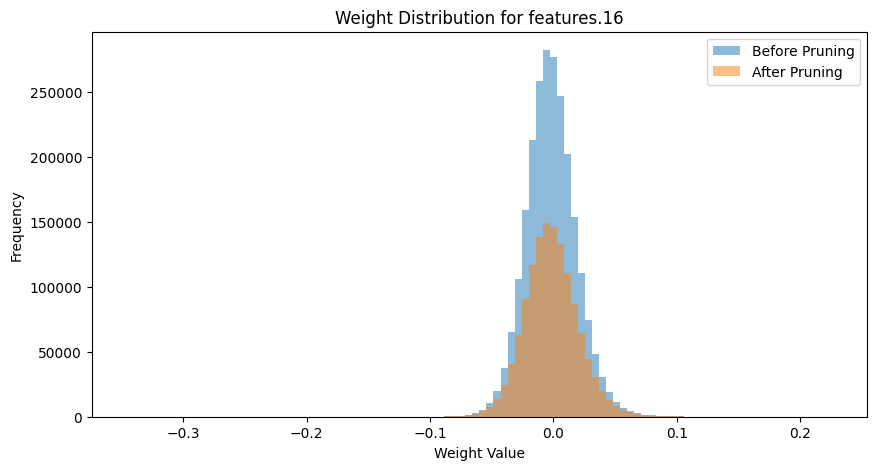

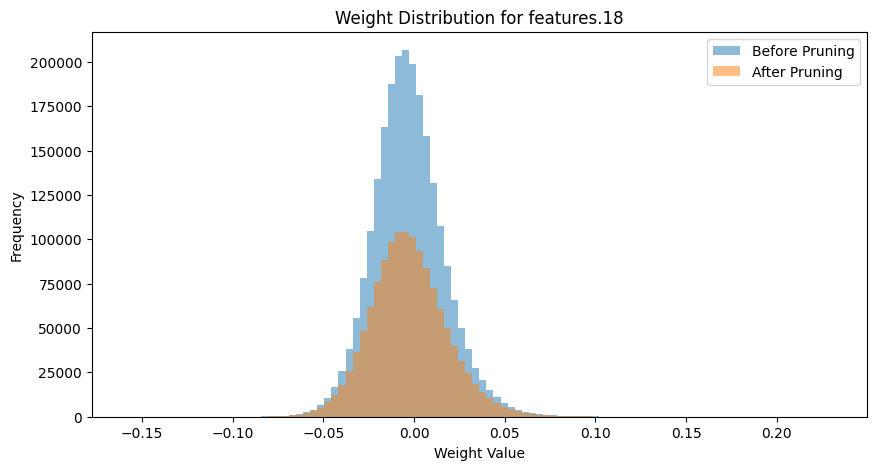

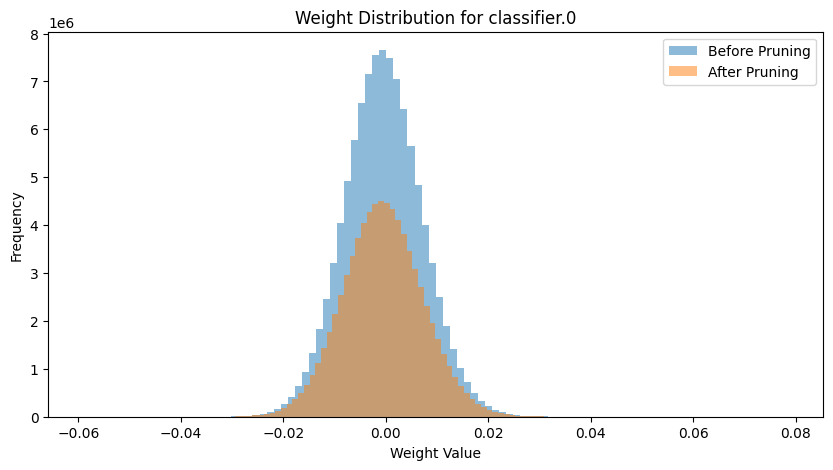

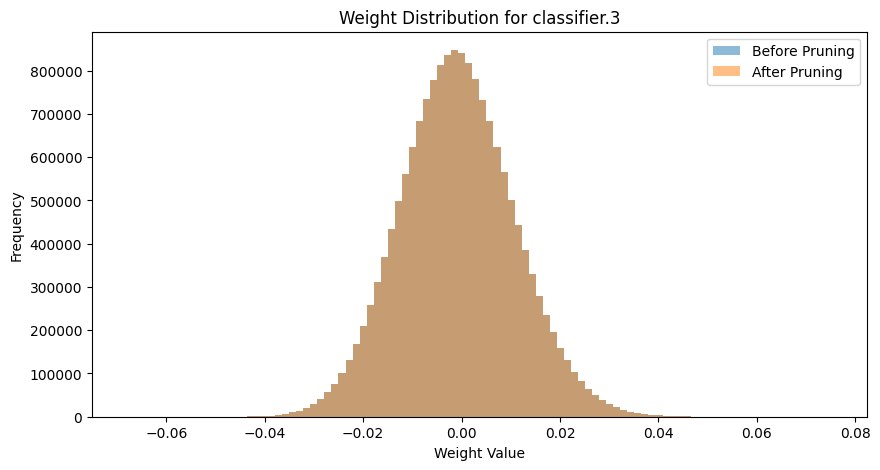

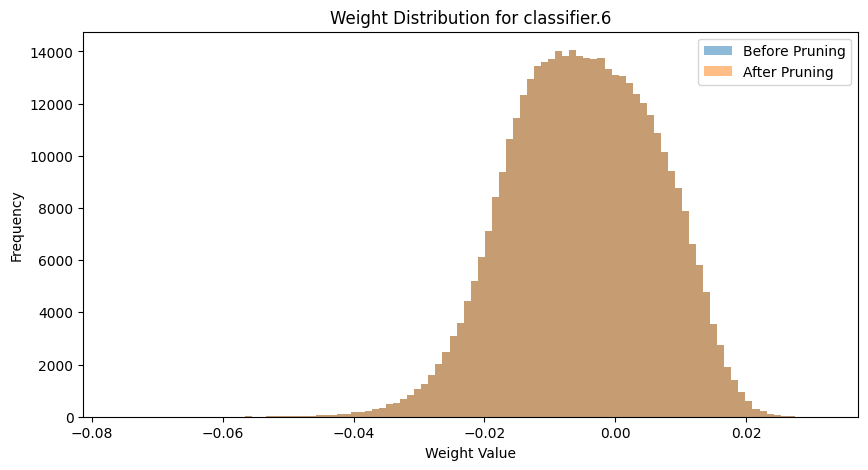

In [ ]:
for layer_name in weights_before.keys():
    plt.figure(figsize=(10, 5))
    plt.hist(weights_before[layer_name], bins=100, alpha=0.5, label='Before Pruning')
    if layer_name in weights_after:
        plt.hist(weights_after[layer_name], bins=100, alpha=0.5, label='After Pruning')
    plt.title(f'Weight Distribution for {layer_name}')
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


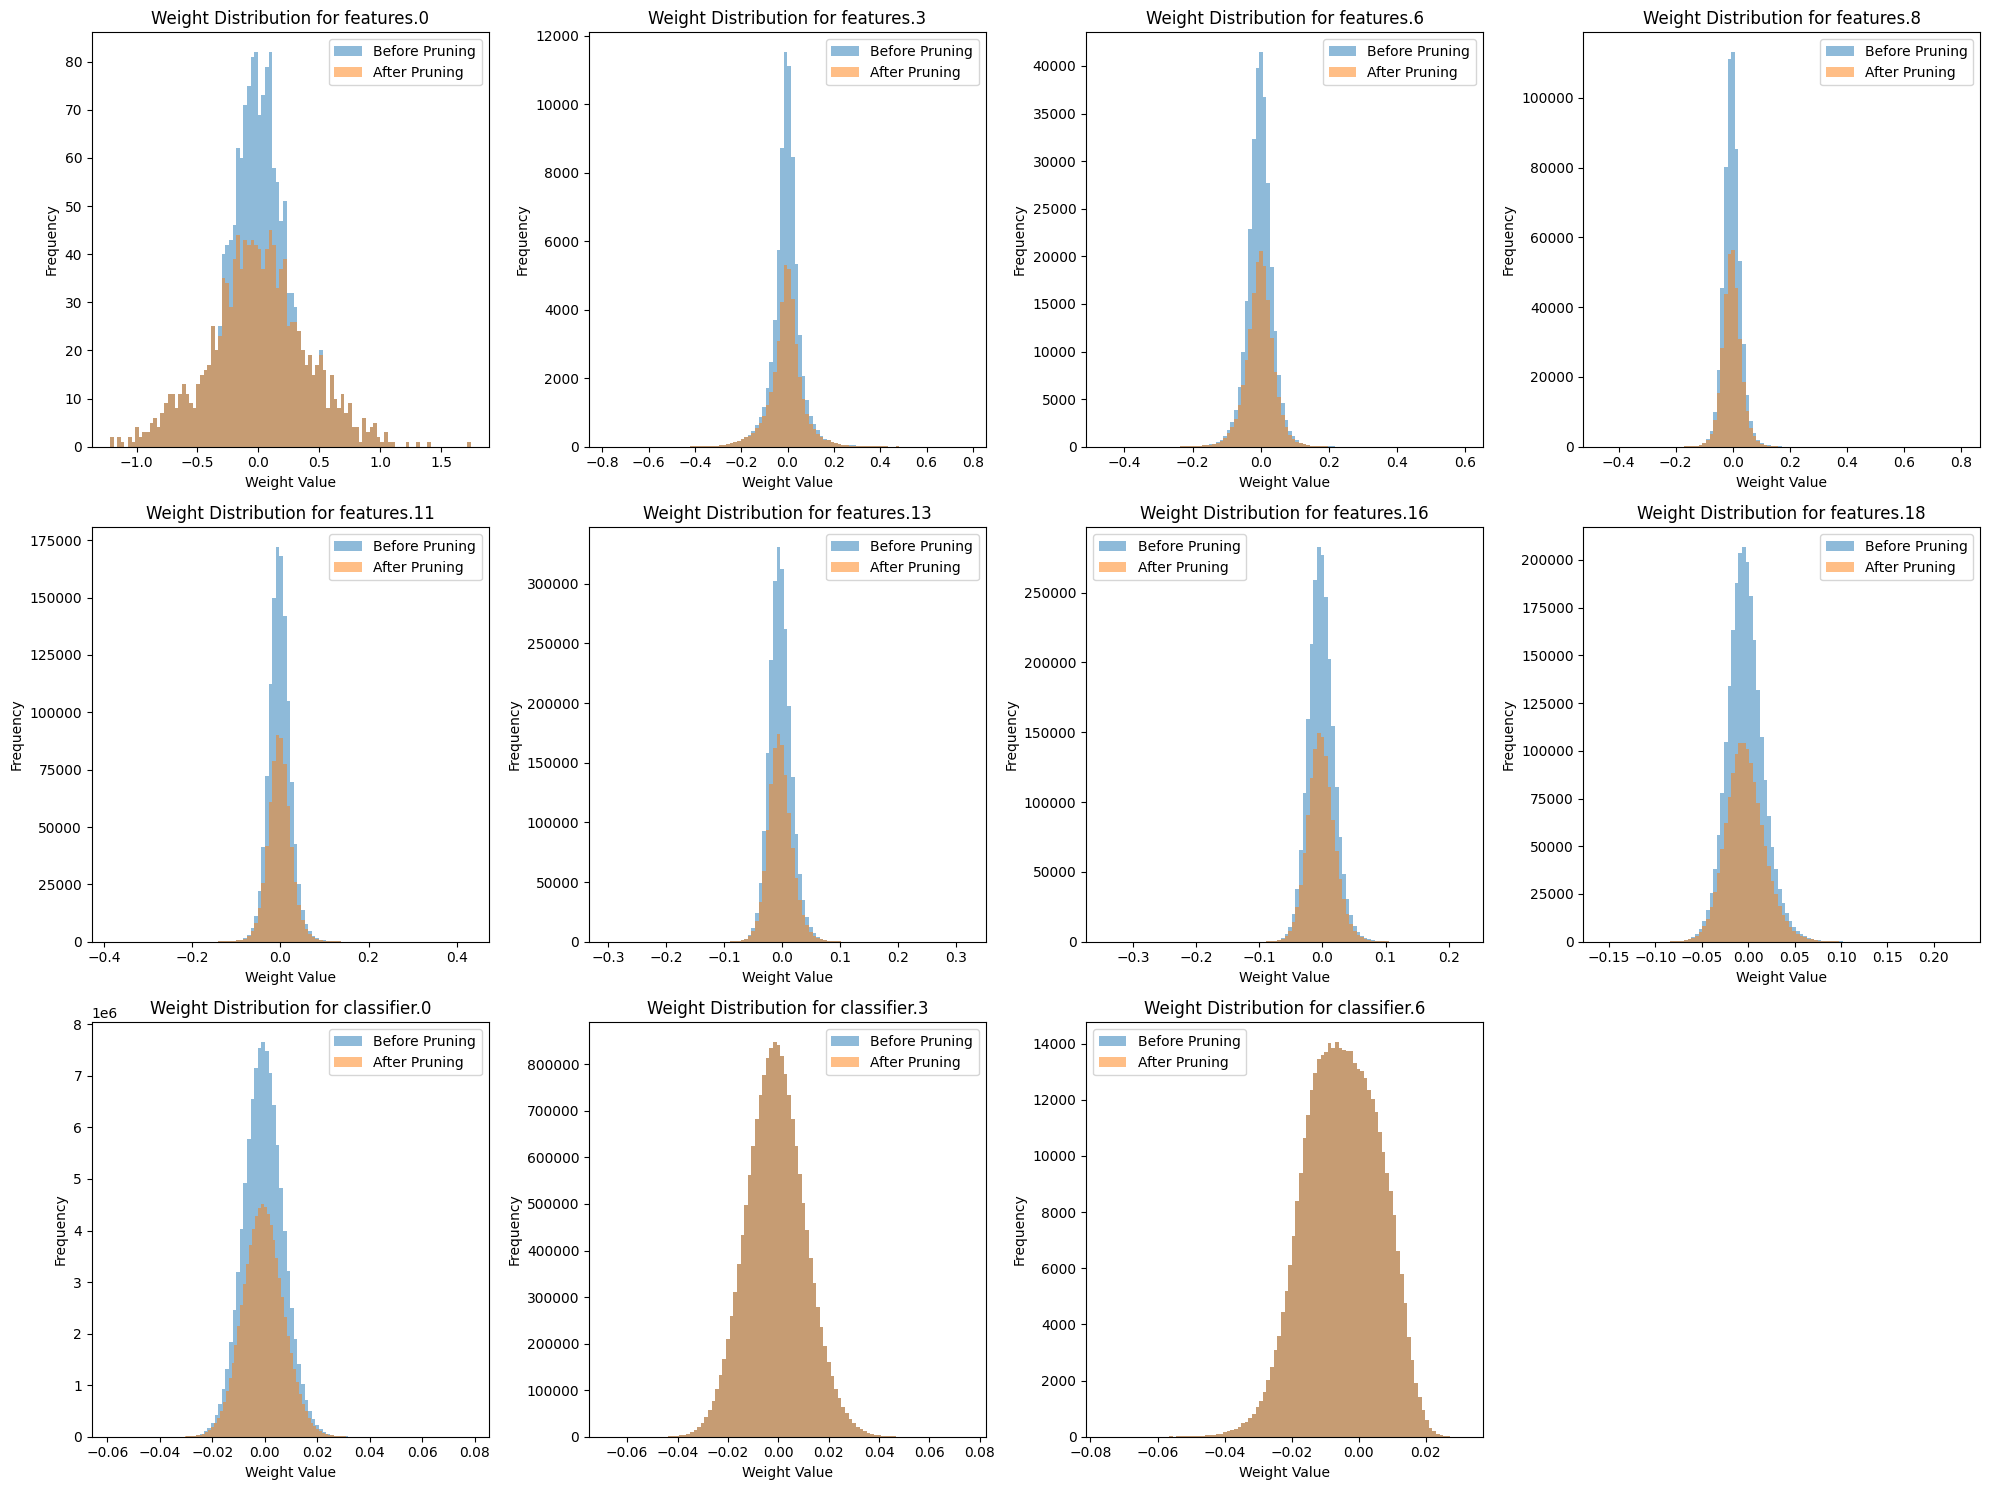

In [ ]:
import matplotlib.pyplot as plt

layer_names = list(weights_before.keys())
num_layers = len(layer_names)

# Determine the grid size
cols = 4
rows = (num_layers + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for idx, layer_name in enumerate(layer_names):
    ax = axes[idx]
    ax.hist(weights_before[layer_name], bins=100, alpha=0.5, label='Before Pruning')
    if layer_name in weights_after:
        ax.hist(weights_after[layer_name], bins=100, alpha=0.5, label='After Pruning')
    ax.set_title(f'Weight Distribution for {layer_name}')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Frequency')
    ax.legend()

# Remove unused subplots
for idx in range(len(layer_names), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('weight_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
accuracy_after_random = test(model,testloader)

100%|██████████| 157/157 [00:19<00:00,  8.06batch/s]

2265
10000
Accuracy on test set: 22.65%


In [ ]:
sparsity_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]


In [ ]:
model = models.vgg11(weights=VGG11_Weights.DEFAULT)
model.classifier[6] = nn.Linear(4096, 100)
model = model.to(device)

In [ ]:
sensitivity_results = {}

model.load_state_dict(torch.load('vgg11_trained.pth'))

for layer_name in layer_names:
    print(f"=====================================================layer name : {layer_name} is starting============================================================")
    accuracies = []
    for sparsity in sparsity_ratios:
        print("sparsity ratio is: ", sparsity)
        temp_model = copy.deepcopy(model)
        module = dict(temp_model.named_modules())[layer_name]
        num_channels = module.out_channels
        num_channels_to_prune = int(num_channels * sparsity)
        print(f"num of channels to prune is: {num_channels_to_prune}")
        if num_channels_to_prune >= num_channels:
            num_channels_to_prune = num_channels - 1  # Ensure at least one channel remains
        # Prune the layer
        prune_conv_layer_classifier_fix(temp_model, layer_name, num_channels_to_prune)
        # Test accuracy
        try:
            accuracy = test(temp_model, testloader)
            accuracies.append(accuracy)
        except Exception as e:
            print(f'Error pruning layer {layer_name} at sparsity {sparsity}: {e}')
            accuracies.append(0)  # Assign zero accuracy in case of error
    # print(f"=====================================================layer name : {layer_name} is done============================================================")
    sensitivity_results[layer_name] = accuracies




/tmp/ipykernel_30/2011599033.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vgg11_trained.pth'))


=====================================================layer name : features.0 is starting============================================================
sparsity ratio is:  0.1
num of channels to prune is: 6
num filter is:  64


100%|██████████| 157/157 [00:25<00:00,  6.09batch/s]


7180
10000
Accuracy on test set: 71.80%
sparsity ratio is:  0.3
num of channels to prune is: 19
num filter is:  64


100%|██████████| 157/157 [00:25<00:00,  6.24batch/s]


...

6022
10000
Accuracy on test set: 60.22%
sparsity ratio is:  0.7
num of channels to prune is: 358
num filter is:  512
Output shape before flattening: torch.Size([1, 154, 7, 7])


100%|██████████| 157/157 [00:25<00:00,  6.15batch/s]


4700
10000
Accuracy on test set: 47.00%
sparsity ratio is:  0.9
num of channels to prune is: 460
num filter is:  512
Output shape before flattening: torch.Size([1, 52, 7, 7])


100%|██████████| 157/157 [00:24<00:00,  6.30batch/s]

2513
10000
Accuracy on test set: 25.13%


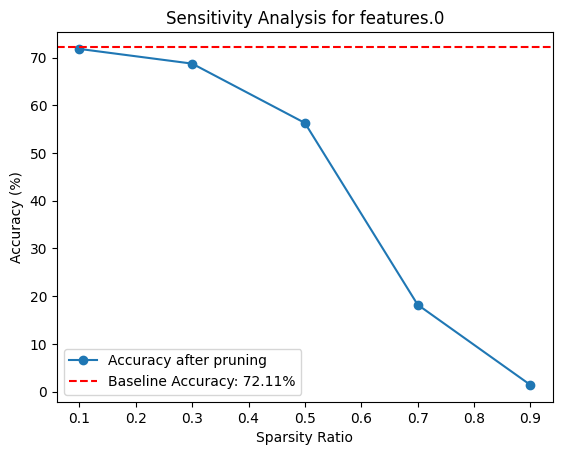

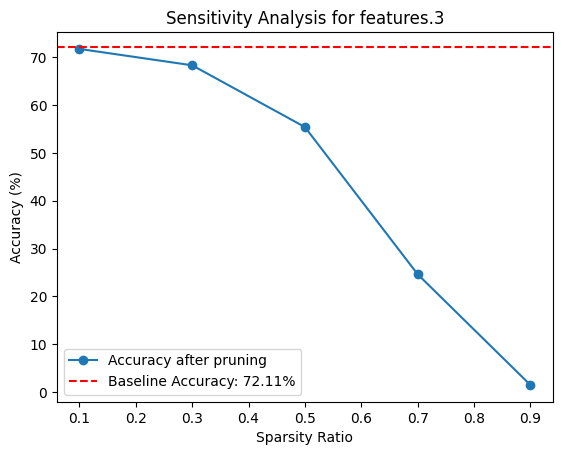

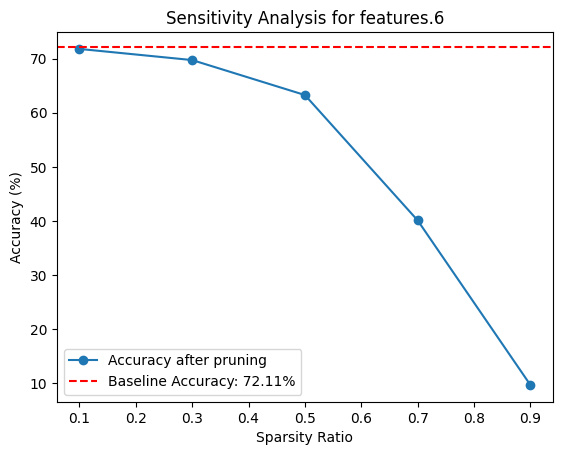

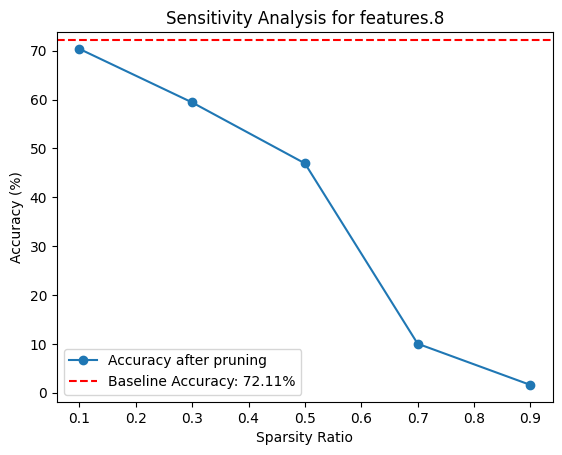

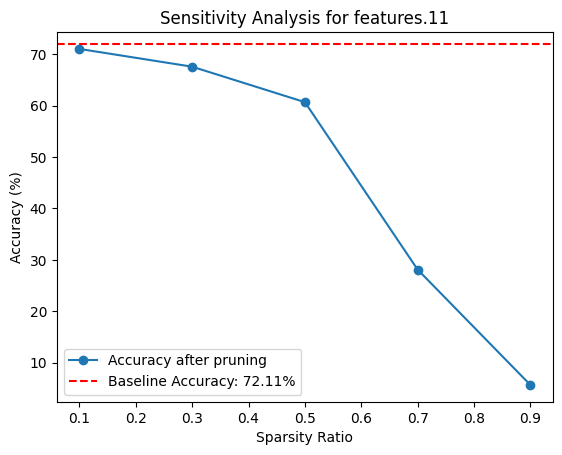

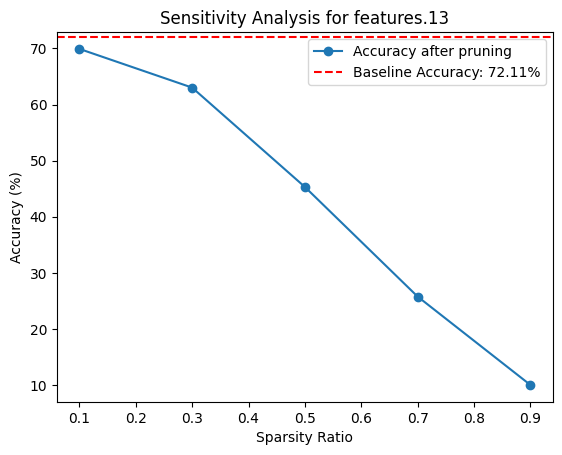

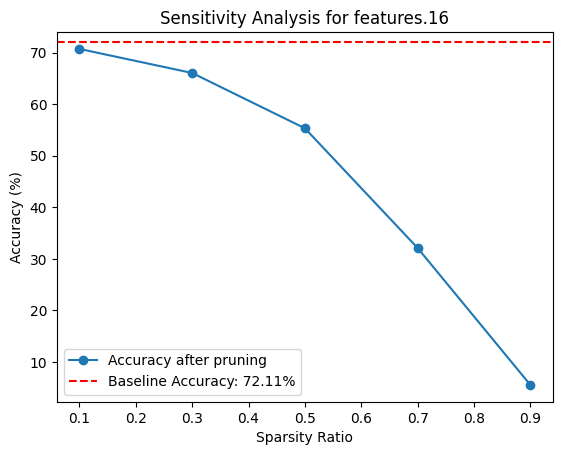

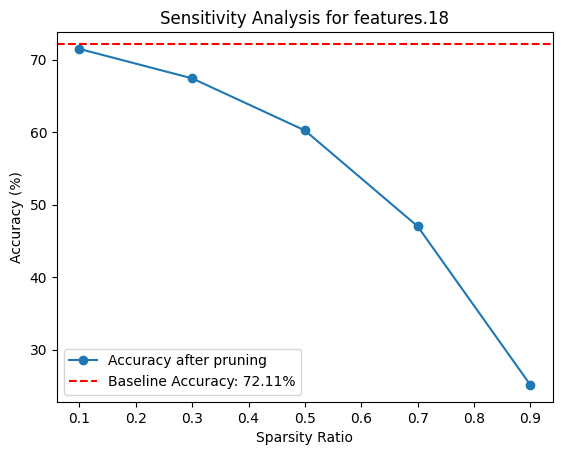

In [ ]:
for layer_name in sensitivity_results:
    plt.figure()
    plt.plot(sparsity_ratios, sensitivity_results[layer_name], marker='o', label="Accuracy after pruning")
    plt.axhline(y=72.11, color='r', linestyle='--', label=f"Baseline Accuracy: {72.11}%")
    plt.xlabel("Sparsity Ratio")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Sensitivity Analysis for {layer_name}")
    plt.legend()
    plt.show()

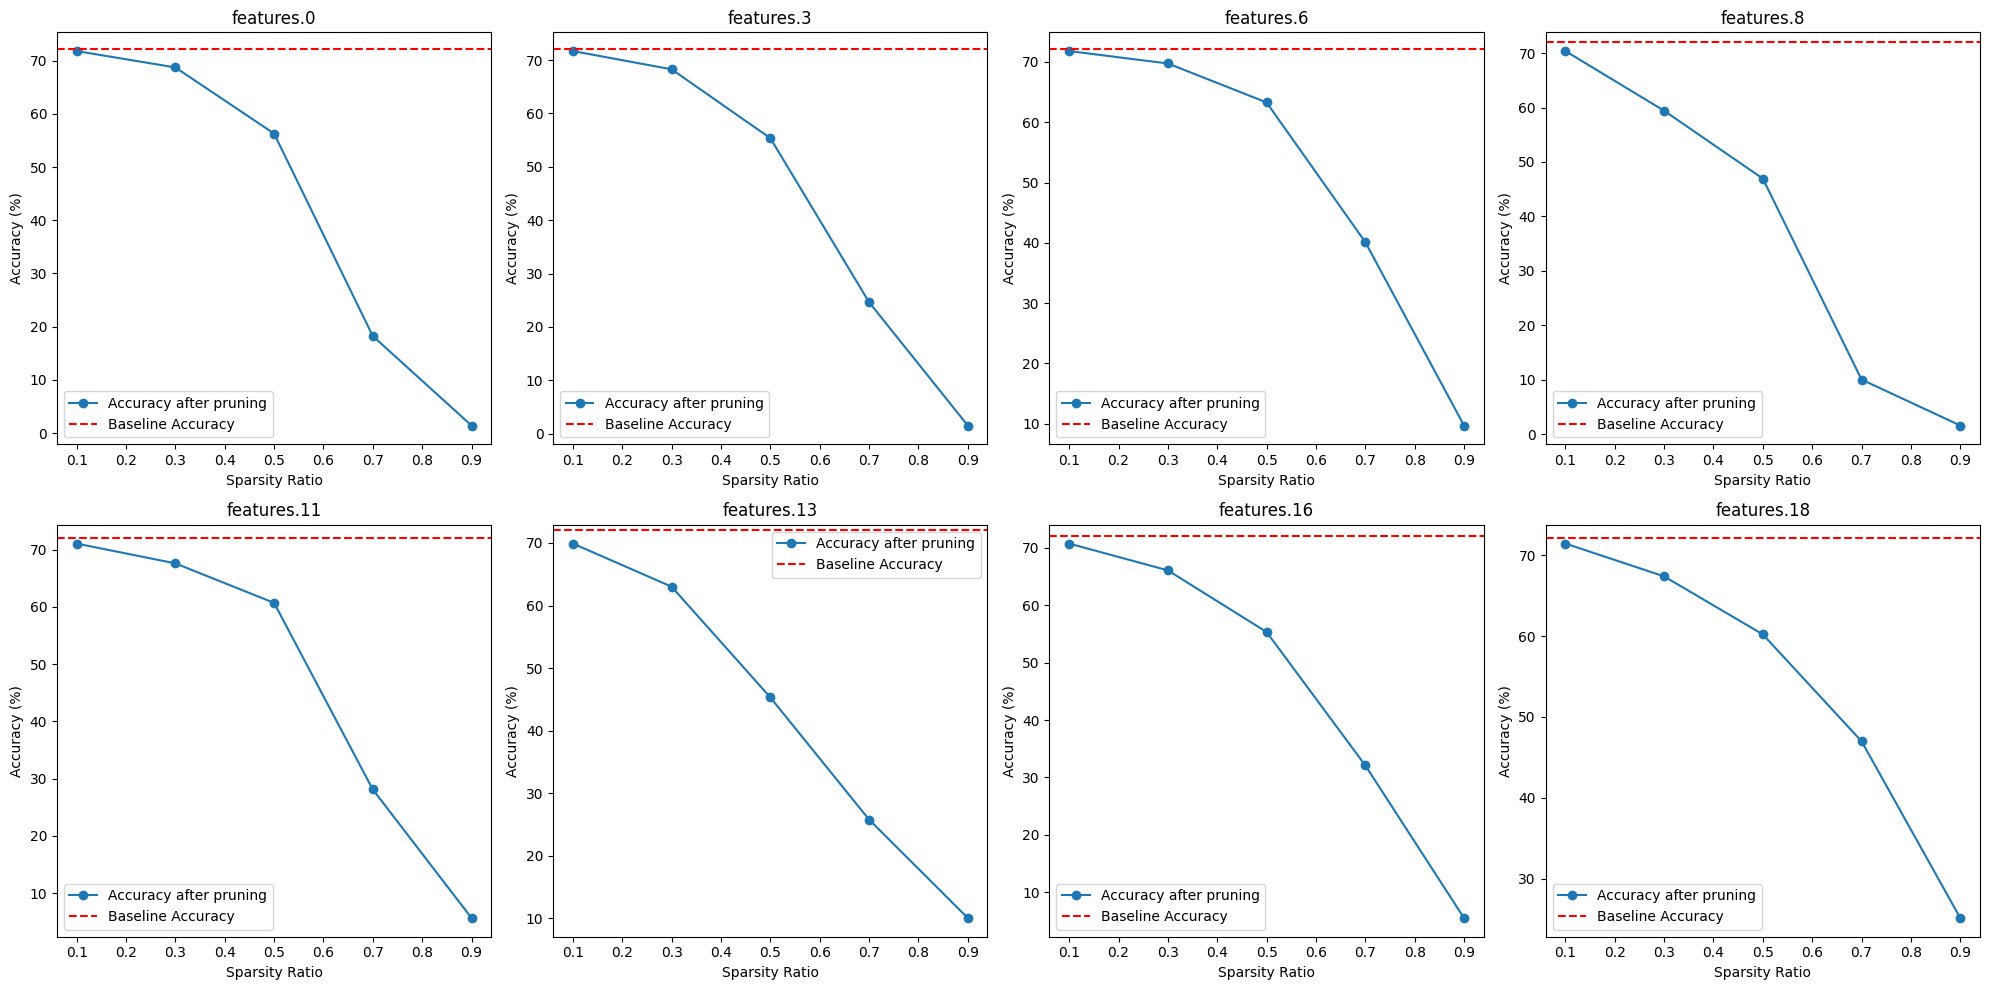

In [ ]:
import matplotlib.pyplot as plt


rows = 2
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(20, 10))
axes = axes.flatten()

for ax, (layer_name, accuracies) in zip(axes, sensitivity_results.items()):
    ax.plot(
        sparsity_ratios,
        accuracies,
        marker='o',
        label="Accuracy after pruning"
    )
    ax.axhline(y=72.11, color='r', linestyle='--', label="Baseline Accuracy")
    ax.set_xlabel("Sparsity Ratio")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"{layer_name}")
    ax.legend()

for ax in axes[len(sensitivity_results):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [ ]:
model = models.vgg11(weights=VGG11_Weights.DEFAULT)
model.classifier[6] = nn.Linear(4096, 100)
model = model.to(device)

In [ ]:
layer_sparsity = {}
for name in layer_names:
    if name in ['features.0', 'features.8', 'features.3']:
        layer_sparsity[name] = 0.0
    elif name in ['features.13', 'features.11', 'features.6']:
        layer_sparsity[name] = 0.2
    elif name in ['features.16', 'features.18']:
        layer_sparsity[name] = 0.28


In [ ]:
def count_total_parameters(model):
    total_params = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            total_params += module.weight.numel()
            if module.bias is not None:
                total_params += module.bias.numel()
    return total_params

# total_params_before = count_total_parameters(model)
# print(f"total parans before: {total_params_before}")

In [ ]:
# Load the pre-trained model
model.load_state_dict(torch.load('vgg11_trained.pth'))

# Calculate total parameters before pruning
total_params_before = count_total_parameters(model)
print(f"Total parameters before pruning: {total_params_before}")

/tmp/ipykernel_30/542426589.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vgg11_trained.pth'))


Total parameters before pruning: 129176036


In [ ]:
def compute_model_size(num_params):
    size_in_bytes = num_params * 4  # Each parameter is 4 bytes (32 bits)
    size_in_mb = size_in_bytes / (1024 ** 2)  # Convert bytes to megabytes
    return size_in_mb

model_size_before = compute_model_size(total_params_before)
print(f"Model size before pruning: {model_size_before:.2f} MB")

Model size before pruning: 492.77 MB


In [ ]:
# def estimate_pruned_parameters(model, layer_sparsity):
#     total_params = 0
#     for name, module in model.named_modules():
#         if isinstance(module, nn.Conv2d):
#             num_params = module.weight.data.numel()
#             sparsity = layer_sparsity.get(name, 0)
#             num_channels = module.out_channels
#             num_channels_to_prune = int(num_channels * sparsity)
#             new_num_channels = num_channels - num_channels_to_prune
#             params_per_channel = num_params // num_channels
#             total_params += new_num_channels * params_per_channel
#         elif isinstance(module, nn.Linear):
#             total_params += module.weight.data.numel()
#     return total_params

# estimated_params_after = estimate_pruned_parameters(model, layer_sparsity)
# print(f"estimated params after: {estimated_params_after}")
# memory_reduction = (1 - estimated_params_after / total_params_before) * 100
# print(f'Estimated Memory Reduction: {memory_reduction:.2f}%')


estimated params after: 126991168
Estimated Memory Reduction: 1.69%


In [ ]:
# Load the trained model before pruning
model.load_state_dict(torch.load('vgg11_trained.pth'))

# Prune the model
for name in layer_names:
    print(f"layer name: {name}")
    sparsity = layer_sparsity.get(name, 0)
    print(f"sparsity induced: {sparsity}")
    if sparsity > 0:
        module = dict(model.named_modules())[name]
        num_channels = module.out_channels
        num_channels_to_prune = int(num_channels * sparsity)
        prune_conv_layer_classifier_fix(model, name, num_channels_to_prune)

/tmp/ipykernel_30/1385640374.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vgg11_trained.pth'))


layer name: features.0
sparsity induced: 0.0
layer name: features.3
sparsity induced: 0.0
layer name: features.6
sparsity induced: 0.2
num filter is:  256
layer name: features.8
sparsity induced: 0.0
layer name: features.11
sparsity induced: 0.2
num filter is:  512
layer name: features.13
sparsity induced: 0.2
num filter is:  512
layer name: features.16
sparsity induced: 0.28
num filter is:  512
layer name: features.18
sparsity induced: 0.28
num filter is:  512
Output shape before flattening: torch.Size([1, 369, 7, 7])


In [ ]:
total_params_after = count_total_parameters(model)
memory_reduction = (1 - total_params_after / total_params_before) * 100
print(f'Actual Memory Reduction: {memory_reduction:.2f}%')

Actual Memory Reduction: 24.84%


In [ ]:
model_size_after = compute_model_size(total_params_after)
print(f"Model size after pruning: {model_size_after:.2f} MB")

Model size after pruning: 370.35 MB


In [ ]:
acc_before_ft = test(model,testloader)

100%|██████████| 157/157 [00:23<00:00,  6.63batch/s]

4428
10000
Accuracy on test set: 44.28%


In [ ]:
torch.save(model.state_dict(), 'vgg11_trained_pruned_structured_BF.pth')

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

In [ ]:
train(model, trainloader, criterion, optimizer, num_epochs=3)

Epoch 3: 100%|██████████| 782/782 [05:49<00:00,  2.23batch/s, accuracy=95.5, loss=0.162]

Finished Training


In [ ]:
acc_AFTER_ft = test(model,testloader)

100%|██████████| 157/157 [00:23<00:00,  6.70batch/s]

6924
10000
Accuracy on test set: 69.24%


In [ ]:
torch.save(model.state_dict(), 'vgg11_trained_pruned_structured_AF.pth')

In [ ]:
inference_time_after = measure_inference_time(model, device)

Average inference time over 100 runs: 4.25 ms


In [ ]:

speedup = inference_time_before / inference_time_after
print(f"Inference time before pruning: {inference_time_before * 1000:.2f} ms")
print(f"Inference time after pruning: {inference_time_after * 1000:.2f} ms")
print(f"Speedup factor: {speedup:.2f}x")


Inference time before pruning: 5.39 ms
Inference time after pruning: 4.25 ms
Speedup factor: 1.27x


# task 1.3

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.4-py3-none-any.whl size=39587 sha256=9be938d9de8ad69d3789883b5164a99e50907da74adce4fcdaa0886ec24d3786
  Stored in directory: /root/.cache/pip/wheels/50/b0/82/1f97b5348c7fe9f0ce0ba18497202cafa5dec4562bd5292680
Successfully built grad-cam


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

# Import grad-cam library components
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Function to load the model
def load_model(model_path):
    model = models.vgg11(weights=VGG11_Weights.DEFAULT)
    model.classifier[6] = nn.Linear(4096, 100)
    # Load the saved weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

# Load the models
baseline_model = load_model('vgg11_trained.pth')







/tmp/ipykernel_30/3077148747.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


In [ ]:
def load_model(model_path):
    model = models.vgg11(weights=VGG11_Weights.DEFAULT)
    model.classifier[6] = nn.Linear(4096, 100)
    layer_sparsity = {
        'features.0': 0.0,
        'features.3': 0.15,
        'features.6': 0.15,
        'features.8': 0.15,
        'features.11': 0.15,
        'features.13': 0.15,
        'features.16': 0.15,
        'features.18': 0.15,
        'classifier.0': 0.26,
        'classifier.3': 0.26,
        'classifier.6': 0.0
    }
    prune_model_per_layer(model, layer_sparsity)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

unstructured_pruned_model = load_model('vgg11_trained_pruned_unstructured_AF.pth')

/tmp/ipykernel_30/4277352815.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


In [ ]:
def load_cus_model(model_path):
    model = models.vgg11(weights=VGG11_Weights.DEFAULT)
    model.classifier[6] = nn.Linear(4096, 100)
    model.to(device)
    layer_sparsity = {}
    for name in layer_names:
        if name in ['features.0', 'features.8', 'features.3']:
            layer_sparsity[name] = 0.0
        elif name in ['features.13', 'features.11', 'features.6']:
            layer_sparsity[name] = 0.2
        elif name in ['features.16', 'features.18']:
            layer_sparsity[name] = 0.28
    # Load the trained model before pruning
    model.load_state_dict(torch.load('vgg11_trained.pth'))

    # Prune the model
    for name in layer_names:
        print(f"layer name: {name}")
        sparsity = layer_sparsity.get(name, 0)
        print(f"sparsity induced: {sparsity}")
        if sparsity > 0:
            module = dict(model.named_modules())[name]
            num_channels = module.out_channels
            num_channels_to_prune = int(num_channels * sparsity)
            prune_conv_layer_classifier_fix(model, name, num_channels_to_prune)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model

structured_pruned_model = load_cus_model('vgg11_trained_pruned_structured_AF.pth')


/tmp/ipykernel_30/675437967.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('vgg11_trained.pth'))


layer name: features.0
sparsity induced: 0.0
layer name: features.3
sparsity induced: 0.0
layer name: features.6
sparsity induced: 0.2
num filter is:  256
layer name: features.8
sparsity induced: 0.0
layer name: features.11
sparsity induced: 0.2
num filter is:  512
layer name: features.13
sparsity induced: 0.2
num filter is:  512
layer name: features.16
sparsity induced: 0.28
num filter is:  512
layer name: features.18
sparsity induced: 0.28
num filter is:  512
Output shape before flattening: torch.Size([1, 369, 7, 7])


/tmp/ipykernel_30/675437967.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


In [ ]:
# Image preprocessing function
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

# Load the image
img_path = '/kaggle/input/horses/horses.jpg'
original_image = Image.open(img_path).convert('RGB')
input_tensor = preprocess(original_image).unsqueeze(0).to(device)  # Add batch dimension

# Convert the image to NumPy array for visualization
original_image_np = np.array(original_image.resize((224, 224))) / 255.0

In [ ]:

def apply_gradcam_pytorch_gradcam(model, model_name, class_idx=None):
    target_layers = [model.features[-3]]
    print(f"Target layers: {target_layers}")

    cam = GradCAM(model=model, target_layers=target_layers)

    outputs = model(input_tensor)
    print(f"Model outputs (raw logits):\n{outputs}")

    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    top_prob, top_catid = torch.topk(probabilities, 5)
    print("Top 5 Predictions:")
    for i in range(top_prob.size(1)):
        class_id = top_catid[0][i].item()
        prob = top_prob[0][i].item()
        class_name = class_names[class_id] if 'class_names' in globals() and class_id in class_names else str(class_id)
        print(f"Class ID: {class_id}, Class Name: {class_name}, Probability: {prob:.4f}")

    if class_idx is not None:
        targets = [ClassifierOutputTarget(class_idx)]
        print(f"Using specified target class: {class_idx}")
    else:
        _, predicted_class = outputs.max(1)
        print(f"Predicted class index: {predicted_class.item()}")
        targets = [ClassifierOutputTarget(predicted_class.item())]
        print(f"Targets: {targets}")


    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    visualization = show_cam_on_image(original_image_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(8, 8))
    plt.imshow(visualization)
    plt.axis('off')
    plt.title(f'Grad-CAM - {model_name}')
    plt.show()


Target layers: [Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))]
Model outputs (raw logits):
tensor([[-8.3059, -6.7191, -6.1942, -4.6265, -5.6566, -7.0452, -6.7334, -6.1840,
         -7.1435, -5.5429, -8.6795, -5.5352, -4.3737, -5.2733, -6.3425, -5.4657,
         -6.8692, -4.6120, -4.1494, -4.7997, -7.5200, -6.4311, -7.6968, -4.3311,
         -5.5893, -5.3778, -8.4497, -5.4103, -8.2629, -4.8787, -5.8934, -4.2091,
         -6.5189, -2.7072, -3.7568, -5.5212, -5.8616, -4.3232, -5.0700, -2.6894,
         -5.7663, -7.1725, -3.7639, -7.2228, -5.9224, -5.8529, -5.1289, -5.4247,
         -8.0282, -5.6353, -5.5887, -6.3542, -4.9455, -8.2660, -7.2393, -5.7004,
         -5.5336, -6.5471, -8.2787, -4.6612, -4.3099, -9.0846, -6.3286, -4.7780,
         -4.8309, -5.6594, -6.1126, -7.0853, -4.5778, -4.8376, -7.6958, -5.4113,
         -5.8547, -5.8242, -5.2058, -5.2075, -2.9830, -7.2256, -7.6662, -5.0813,
         -4.1055, -4.8734, -4.6305, -6.1135, -6.7606, -6.3787, -8.4898, -6.90

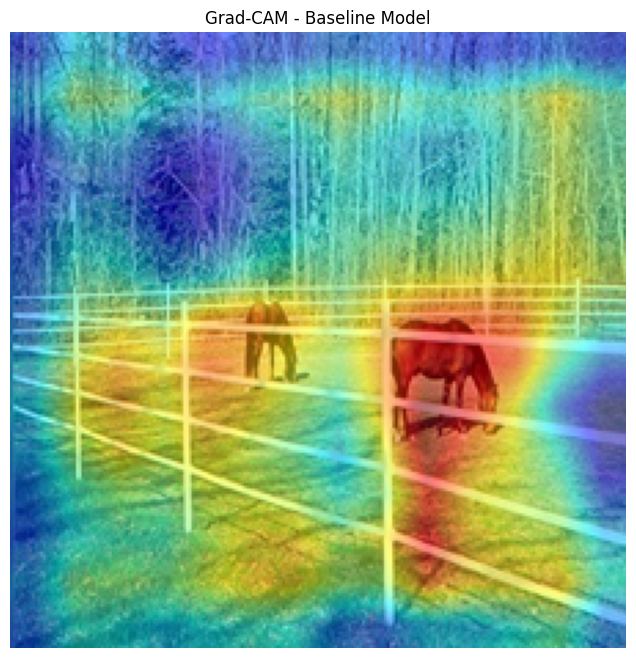

In [ ]:

# Baseline Model
apply_gradcam_pytorch_gradcam(baseline_model, 'Baseline Model')



Target layers: [Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))]
Model outputs (raw logits):
tensor([[-10.1029,  -7.8099,  -7.4611,  -8.1436, -11.7293,  -8.1000,  -9.0291,
          -9.0855,  -8.4076,  -6.1426,  -9.8250,  -7.0018,  -7.9915,  -4.8888,
         -10.6670,  -7.5506,  -8.1166,  -7.0281,  -7.7645,  -7.6150, -10.2318,
          -9.6025,  -8.5345,  -6.5127,  -8.7875,  -6.5572,  -9.8578, -11.3461,
         -10.3467,  -7.9701, -10.8474,  -7.9685,  -9.1105,  -6.0907,  -6.9508,
          -8.0532,  -7.6712,  -7.9813, -10.0976,  -4.0026,  -6.8714,  -9.4246,
         -10.4285, -11.0185,  -9.1880,  -7.7973,  -6.4553,  -7.7864,  -9.2223,
          -8.6830,  -8.7860,  -9.1009,  -9.3459,  -7.5235,  -8.4872, -10.4593,
          -9.4674,  -6.8411, -10.0225,  -9.3427,  -6.5156, -10.6425,  -8.2593,
         -10.0205,  -8.6142,  -8.7267,  -9.6567, -11.4619,  -7.3738,  -7.4314,
          -8.2702,  -8.7964,  -9.4350,  -8.1336, -11.2150,  -9.0225,  -5.3850,
         -11.1590,

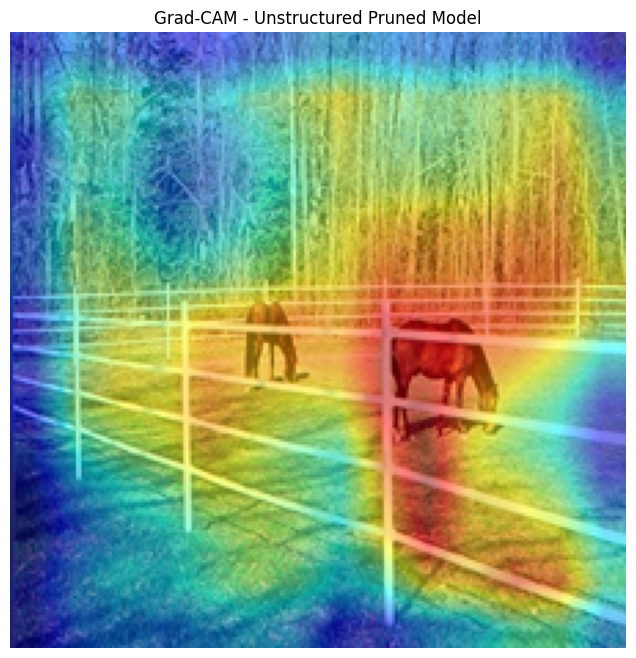

In [ ]:
# Unstructured Pruned Model
apply_gradcam_pytorch_gradcam(unstructured_pruned_model, 'Unstructured Pruned Model')



Target layers: [Conv2d(369, 369, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))]
Model outputs (raw logits):
tensor([[ -9.5196,  -8.3420,  -5.8542,  -7.5215,  -9.1843,  -7.1094,  -7.9676,
          -7.8324,  -5.1547,  -5.5633,  -8.0015,  -4.9830,  -6.0359,  -4.2743,
          -8.5390,  -5.0653,  -8.0948,  -5.8023,  -5.0776,  -5.2419,  -5.9476,
          -8.8056,  -8.0021,  -7.9320,  -6.8908,  -5.0388,  -8.8663,  -8.2241,
          -8.7406,  -4.7924,  -9.6252,  -6.0993,  -8.4093,  -3.3732,  -5.9680,
          -5.7517,  -8.0123,  -4.6520,  -7.1889,  -5.9842,  -6.4348,  -6.0123,
          -8.3302,  -8.7603,  -7.1972,  -5.7632,  -5.2510,  -5.3698,  -6.2685,
          -7.5717,  -8.3439,  -7.6308,  -5.8873,  -8.1251,  -6.5691,  -8.2726,
          -3.8083,  -6.9523,  -6.2833,  -5.0500,  -4.6381,  -9.8539,  -5.7249,
          -7.1103,  -7.1489,  -6.5959,  -6.5680, -10.3044,  -5.0205,  -6.1929,
          -6.6101,  -6.6175,  -8.6132,  -9.1078, -10.0707,  -6.6027,  -4.9856,
          -8.2254,

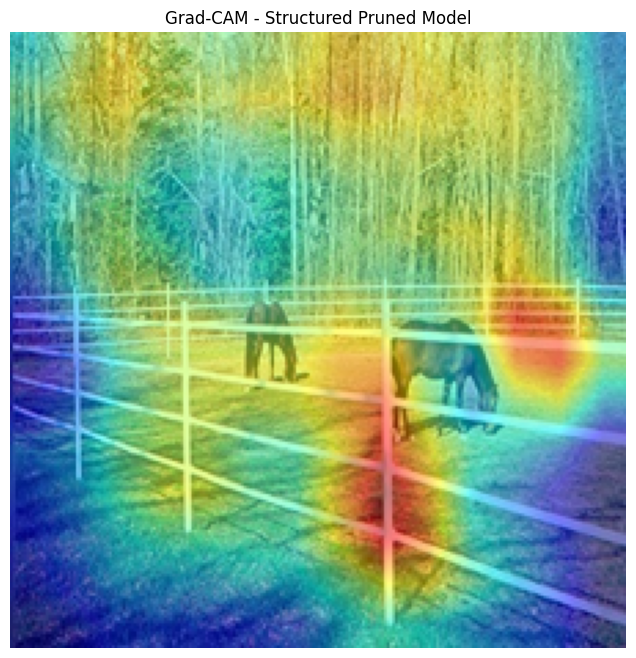

In [ ]:
# Structured Pruned Model
apply_gradcam_pytorch_gradcam(structured_pruned_model, 'Structured Pruned Model')

In [ ]:
import gc

# Before starting training
gc.collect()
torch.cuda.empty_cache()

<ipython-input-14-8bed7913cb92>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/atml_pa3/vgg11_trained (1).pth'))



Unstructured Pruning with target sparsity: 0.0%
Total parameters: 129164992
Number of parameters to prune (k): 1
Pruning threshold: tensor(1.7574e-11, device='cuda:0')
Actual sparsity after pruning: 0.0000


100%|██████████| 157/157 [00:28<00:00,  5.44batch/s]


7211
10000
Accuracy on test set: 72.11%

Unstructured Pruning with target sparsity: 20.0%
Total parameters: 129164992
Number of parameters to prune (k): 25832998
Pruning threshold: tensor(0.0021, device='cuda:0')
Actual sparsity after pruning: 0.2000


100%|██████████| 157/157 [00:28<00:00,  5.55batch/s]


...

100
10000
Accuracy on test set: 1.00%


Epoch 1: 100%|██████████| 782/782 [01:55<00:00,  6.76batch/s, accuracy=20.7, loss=2.7]


Finished Training


100%|██████████| 157/157 [00:20<00:00,  7.78batch/s]


3649
10000
Accuracy on test set: 36.49%


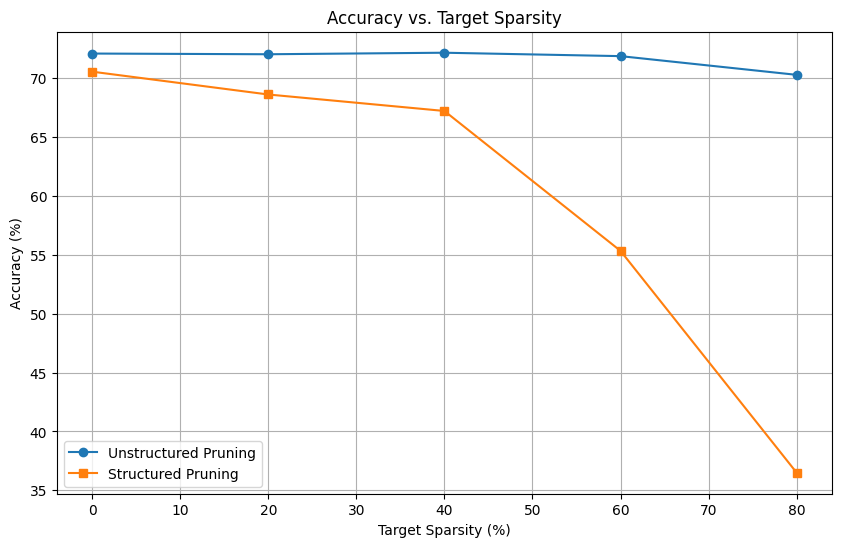

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
import copy
import matplotlib.pyplot as plt

target_sparsity_levels = [0.0, 0.2, 0.4, 0.6, 0.8]

model = models.vgg11(weights=VGG11_Weights.DEFAULT)
model.classifier[6] = nn.Linear(4096, 100)
model = model.to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/atml_pa3/vgg11_trained (1).pth'))

criterion = nn.CrossEntropyLoss()

layer_names = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        layer_names.append(name)

# Evaluate unstructured pruning
def evaluate_unstructured_pruning(model, target_sparsity_levels):
    unstructured_results = []
    for sparsity in target_sparsity_levels:
        print(f"\nUnstructured Pruning with target sparsity: {sparsity*100}%")
        model_copy = copy.deepcopy(model)
        prune_model_unstructured_gpu(model_copy, sparsity)

        accuracy = test(model_copy, testloader)
        unstructured_results.append((sparsity, accuracy))
    return unstructured_results

def get_layerwise_sparsity(model, global_sparsity):
    layer_sparsity = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            layer_sparsity[name] = global_sparsity
    return layer_sparsity


def evaluate_structured_pruning(model, target_sparsity_levels):
    structured_results = []
    for sparsity in target_sparsity_levels:
        print(f"\nStructured Pruning with target sparsity: {sparsity*100}%")
        model_copy = copy.deepcopy(model)
        layer_sparsity = get_layerwise_sparsity(model_copy, sparsity)
        for name in layer_names:
            layer_sparsity_value = layer_sparsity.get(name, 0)
            if layer_sparsity_value > 0:
                module = dict(model_copy.named_modules())[name]
                num_channels = module.out_channels
                num_channels_to_prune = int(num_channels * layer_sparsity_value)
                if num_channels_to_prune >= num_channels:
                    num_channels_to_prune = num_channels - 1
                prune_conv_layer_classifier_fix(model_copy, name, num_channels_to_prune)

        accuracy_before = test(model_copy, testloader)
        # print(f"Accuracy before unstructured pruning at {sparsity*100}% sparsity: {accuracy:.2f}%")
        optimizer = optim.AdamW(model_copy.parameters(), lr=1e-4)
        train(model_copy, trainloader, criterion, optimizer, num_epochs=1)
        accuracy = test(model_copy, testloader)
        # print(f"Accuracy after structured pruning at {sparsity*100}% sparsity: {accuracy:.2f}%")
        structured_results.append((sparsity, accuracy))
    return structured_results


unstructured_results = evaluate_unstructured_pruning(model, target_sparsity_levels)
structured_results = evaluate_structured_pruning(model, target_sparsity_levels)


unstructured_sparsity = [s * 100 for s, _ in unstructured_results]
unstructured_accuracy = [acc for _, acc in unstructured_results]

structured_sparsity = [s * 100 for s, _ in structured_results]
structured_accuracy = [acc for _, acc in structured_results]

plt.figure(figsize=(10, 6))
plt.plot(unstructured_sparsity, unstructured_accuracy, marker='o', label='Unstructured Pruning')
plt.plot(structured_sparsity, structured_accuracy, marker='s', label='Structured Pruning')
plt.xlabel('Target Sparsity (%)')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs. Target Sparsity')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Function to apply global unstructured pruning
def apply_global_unstructured_pruning(model, sparsity):
    parameters_to_prune = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, 'weight'))
    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=sparsity,
    )


def evaluate_unstructured_pruning(model, target_sparsity_levels):
    unstructured_results = []
    for sparsity in target_sparsity_levels:
        print(f"\nUnstructured Pruning with target sparsity: {sparsity*100}%")
        model_copy = copy.deepcopy(model)
        apply_global_unstructured_pruning(model_copy, sparsity)

        accuracy = test(model_copy, testloader)
        # print(f"Accuracy before unstructured pruning at {sparsity*100}% sparsity: {accuracy:.2f}%")
        # optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model_copy.parameters()), lr=1e-4)
        # train(model_copy, trainloader, criterion, optimizer, num_epochs=1)
        # accuracy = test(model_copy, testloader)
        # print(f"Accuracy after unstructured pruning at {sparsity*100}% sparsity: {accuracy:.2f}%")
        unstructured_results.append((sparsity, accuracy))
    return unstructured_results

unstructured_results_l1 = evaluate_unstructured_pruning(model, target_sparsity_levels)


Unstructured Pruning with target sparsity: 0.0%


100%|██████████| 157/157 [00:30<00:00,  5.12batch/s]


7211
10000
Accuracy on test set: 72.11%

Unstructured Pruning with target sparsity: 20.0%


100%|██████████| 157/157 [00:30<00:00,  5.09batch/s]


7205
10000
Accuracy on test set: 72.05%

Unstructured Pruning with target sparsity: 40.0%


...

7218
10000
Accuracy on test set: 72.18%

Unstructured Pruning with target sparsity: 60.0%


100%|██████████| 157/157 [00:30<00:00,  5.11batch/s]


7189
10000
Accuracy on test set: 71.89%

Unstructured Pruning with target sparsity: 80.0%


100%|██████████| 157/157 [00:30<00:00,  5.08batch/s]

7031
10000
Accuracy on test set: 70.31%
